# 스타벅스 마케팅 데이터 분석

In [1]:
# import library
import pandas as pd
import numpy as np
import ast
import re

# 시각화 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick 
plt.rcParams['axes.unicode_minus'] = False 

# 한글 폰트 설정
import platform
if platform.system() == 'Windows': # Windows OS
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # mac OS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

from datetime import datetime, timedelta
from scipy import stats 
import pingouin as pg
import warnings 
import scikit_posthocs as sp 
import re
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 그래프 색상 무작위 지정
import random
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
color=colors

# 모든 컬럼 다 보기
pd.set_option('display.max_columns', None) 

# 시드 설정
np.random.seed(42) # 팀원간의 결과물이 동일하게 보일 수 있게 (논의 필요)

### Load File

In [2]:
# 데이터 원본 로드
df_profile_org = pd.read_csv(r"starbucks/profile.csv")
df_portfolio_org = pd.read_csv(r"starbucks/portfolio.csv")
df_transcript_org = pd.read_csv(r"starbucks/transcript.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'starbucks/profile.csv'

### 데이터셋 확인: 원본 데이터

In [ ]:
# 데이터 행과 열 개수
print(f"df_profile: {df_profile_org.shape}")
print(f"df_portfolio: {df_portfolio_org.shape}")
print(f"df_transcript: {df_transcript_org.shape}")

df_profile: (17000, 6)
df_portfolio: (10, 7)
df_transcript: (306534, 5)


In [4]:
# profile 데이터 타입 확인
df_profile_org.info()
print('-'*50)
# portfolio 데이터 타입 확인
df_portfolio_org.info()
print('-'*50)
# transcript 데이터 타입 확인
df_transcript_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17000 non-null  int64  
 1   gender            14825 non-null  object 
 2   age               17000 non-null  int64  
 3   id                17000 non-null  object 
 4   became_member_on  17000 non-null  int64  
 5   income            14825 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 797.0+ KB
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10 non-null     int64 
 1   reward      10 non-null     int64 
 2   channels    10 non-null     object
 3   difficulty  10 non-null     int64 
 4   duration    10 non-null     int64 
 5   offer_type  10 

In [5]:
# 기술통계 확인
display(df_profile_org.describe(include='all').T) 
display(df_portfolio_org.describe(include='all').T)
display(df_transcript_org.describe(include='all').T) 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,17000.0,NaN,NaN,NaN,8499.5,4907.621624,0.0,4249.75,8499.5,12749.25,16999.0
gender,14825,3,M,8484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,17000.0,NaN,NaN,NaN,62.531412,26.73858,18.0,45.0,58.0,73.0,118.0
id,17000,17000,e4052622e5ba45a8b96b59aba68cf068,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
became_member_on,17000.0,NaN,NaN,NaN,20167034.234118,11677.499961,20130729.0,20160526.0,20170802.0,20171230.0,20180726.0
income,14825.0,NaN,NaN,NaN,65404.991568,21598.29941,30000.0,49000.0,64000.0,80000.0,120000.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,10.0,NaN,NaN,NaN,4.5,3.02765,0.0,2.25,4.5,6.75,9.0
reward,10.0,NaN,NaN,NaN,4.2,3.583915,0.0,2.0,4.0,5.0,10.0
channels,10,4,"['web', 'email', 'mobile', 'social']",4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
difficulty,10.0,NaN,NaN,NaN,7.7,5.831905,0.0,5.0,8.5,10.0,20.0
duration,10.0,NaN,NaN,NaN,6.5,2.321398,3.0,5.0,7.0,7.0,10.0
offer_type,10,3,bogo,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,10,10,ae264e3637204a6fb9bb56bc8210ddfd,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,306534.0,NaN,NaN,NaN,153266.5,88488.888045,0.0,76633.25,153266.5,229899.75,306533.0
person,306534,17000,94de646f7b6041228ca7dec82adb97d2,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event,306534,4,transaction,138953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value,306534,5121,{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'},14983,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,306534.0,NaN,NaN,NaN,366.38294,200.326314,0.0,186.0,408.0,528.0,714.0


In [6]:
# 중복 확인
print(f"profile: {df_profile_org.duplicated().sum():,}건")
print(f"portfolio: {df_portfolio_org.duplicated().sum():,}건")
print(f"transcript: {df_transcript_org.duplicated().sum():,}건")

profile: 0건
portfolio: 0건
transcript: 0건


In [7]:
# 결측치 개수 확인
print('테이블별 컬럼별 결측치 개수')
print('-'*50)
print(f"profile: {df_profile_org.isnull().sum()}건")
print('-'*50)
print(f"portfolio: {df_portfolio_org.isnull().sum()}건")
print('-'*50)
print(f"transcript: {df_transcript_org.isnull().sum()}건")

테이블별 컬럼별 결측치 개수
--------------------------------------------------
profile: Unnamed: 0             0
gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64건
--------------------------------------------------
portfolio: Unnamed: 0    0
reward        0
channels      0
difficulty    0
duration      0
offer_type    0
id            0
dtype: int64건
--------------------------------------------------
transcript: Unnamed: 0    0
person        0
event         0
value         0
time          0
dtype: int64건


In [8]:
# profile 결측치 요소 상세 확인
print(df_profile_org['gender'].unique())
# F: Female (여성)
# M: Male (남성)
# O: 기타 (Other, 또는 Non-binary 등)
print(df_profile_org['income'].unique())

[nan 'F' 'M' 'O']
[    nan 112000. 100000.  70000.  53000.  51000.  57000.  46000.  71000.
  52000.  42000.  40000.  69000.  88000.  59000.  41000.  96000.  89000.
  33000.  68000.  63000.  30000.  98000.  37000.  80000.  48000.  38000.
  56000.  93000.  50000.  35000.  47000.  87000.  76000.  64000.  72000.
 117000.  55000.  77000.  85000.  36000.  91000. 107000.  66000.  58000.
  74000.  84000.  54000.  49000.  73000.  78000.  31000.  60000.  44000.
 114000.  65000.  79000.  67000.  94000. 108000.  61000.  43000.  92000.
  62000.  83000.  34000. 105000.  82000. 118000. 109000.  99000.  45000.
 106000.  95000. 103000. 101000. 110000.  86000.  39000.  75000.  90000.
  81000.  32000. 120000. 119000.  97000. 104000. 113000. 115000. 111000.
 102000. 116000.]


## 1차 전처리

- 결측치 처리
- 불필요한 컬럼 제거
- 컬럼 분리 
    - portfolio['channel'] 컬럼 분리(web, email, mobile, social)
    - transcript['value'] 컬럼 분리(amount, offer id, reward)
- One-hot 인코딩

### portfolio: 1차 전처리

In [9]:
# 불필요한 컬럼(Unnamed: 0) 제거
portfolio_cleaned = df_portfolio_org.drop(columns=['Unnamed: 0'])
portfolio_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reward      10 non-null     int64 
 1   channels    10 non-null     object
 2   difficulty  10 non-null     int64 
 3   duration    10 non-null     int64 
 4   offer_type  10 non-null     object
 5   id          10 non-null     object
dtypes: int64(3), object(3)
memory usage: 608.0+ bytes


In [10]:
# portfolio['channel'] 컬럼 분리 및 One-hot 인코딩

import ast
df = portfolio_cleaned.copy()

# --- 0. 중복 컬럼 정리 및 데이터 타입 변환 ---
# 기존 원-핫 인코딩된 채널 컬럼들을 삭제(중복 방지)
channels_to_drop = ['web', 'email', 'mobile', 'social']
for col in channels_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])
        
# 불필요한 'Unnamed: 0' 컬럼 정리
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 'channels' 컬럼 타입이 문자열이라면 리스트로 변환
try:
    df['channels'] = df['channels'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
except:
    print("channels 컬럼이 이미 리스트이거나, ast.literal_eval로 변환할 수 없는 형태입니다. 변환 단계를 건너뜁니다.")

# --- 1. 리스트를 쉼표로 구분된 문자열로 변환하여 임시 컬럼 'channels_str' 생성 ---
df['channels_str'] = df['channels'].apply(lambda x: ','.join(x))

# --- 2. str.get_dummies()로 원-핫 인코딩 수행 ---
channel_dummies = df['channels_str'].str.get_dummies(sep=',')

# --- 3. 원본에 결합 및 정리 (원본 channels 보존) ---

# 원본 DataFrame에 원-핫 인코딩 결과 결합
df = pd.concat([df, channel_dummies], axis=1)

# 불필요한 임시 컬럼 'channels_str' 제거
df = df.drop(columns=['channels_str'])

# 최종 결과를 portfolio_clean에 할당
portfolio_final = df

print("\n✅ 데이터 변환 및 원-핫 인코딩 완료 (중복 컬럼 제거).")
print(f"원본 channels (첫 행): {portfolio_cleaned['channels'].iloc[0]}")
print(f"인코딩 결과 (첫 행): web={portfolio_final['web'].iloc[0]}, email={portfolio_final['email'].iloc[0]}, mobile={portfolio_final['mobile'].iloc[0]}, social={portfolio_final['social'].iloc[0]}")
print("\n🔥 DataFrame의 컬럼 목록 확인 (중복이 없는지 확인):")
print(portfolio_final.columns)


✅ 데이터 변환 및 원-핫 인코딩 완료 (중복 컬럼 제거).
원본 channels (첫 행): ['email', 'mobile', 'social']
인코딩 결과 (첫 행): web=0, email=1, mobile=1, social=1

🔥 DataFrame의 컬럼 목록 확인 (중복이 없는지 확인):
Index(['reward', 'channels', 'difficulty', 'duration', 'offer_type', 'id',
       'email', 'mobile', 'social', 'web'],
      dtype='object')


In [11]:
# 필요한 컬럼들만 추출 
portfolio_real_final = portfolio_final[['reward', 'difficulty', 'duration', 'offer_type', 'id', 'email', 'mobile', 'social', 'web']]


### profile: 1차 전처리

In [12]:
# became_member_on 컬럼 데이터 타입 변경
df_profile_clean = df_profile_org.copy()
df_profile_clean['became_member_on'] = pd.to_datetime(df_profile_clean['became_member_on'], format='%Y%m%d')
print(f"데이터 타입 변환 전 : {df_profile_org.info()}")
print('-'*50)
print(f"데이터 타입 변환 후 : {df_profile_clean.info()}")

# df_profile_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17000 non-null  int64  
 1   gender            14825 non-null  object 
 2   age               17000 non-null  int64  
 3   id                17000 non-null  object 
 4   became_member_on  17000 non-null  int64  
 5   income            14825 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 797.0+ KB
데이터 타입 변환 전 : None
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Unnamed: 0        17000 non-null  int64         
 1   gender            14825 non-null  object        
 2   age               17000 non-null  int64         
 3  

In [13]:
# profile 결측치 제거
profile_clean = df_profile_clean.dropna()
print(f"결측치 제거 전 : {df_profile_org.shape[0]}행 / {df_profile_org.shape[1]}열")
print(f"결측치 제거 후 : {profile_clean.shape[0]}행 / {profile_clean.shape[1]}열")
print(f"제거된 행 수 : {df_profile_org.shape[0] - profile_clean.shape[0]}행")
print('-'*50)
profile_clean.info()

결측치 제거 전 : 17000행 / 6열
결측치 제거 후 : 14825행 / 6열
제거된 행 수 : 2175행
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 14825 entries, 1 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Unnamed: 0        14825 non-null  int64         
 1   gender            14825 non-null  object        
 2   age               14825 non-null  int64         
 3   id                14825 non-null  object        
 4   became_member_on  14825 non-null  datetime64[ns]
 5   income            14825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 810.7+ KB


In [14]:
# 불필요한 컬럼(Unnamed: 0) 제거
profile_clean = profile_clean.drop(columns='Unnamed: 0')

### Transcript: 1차 전처리

In [15]:
# value 컬럼 분리 -> 'offer id', 'reward', 'amount'
import numpy as np
import ast

# 🆕 원본 복사본 생성
df_transcript_cleaned = df_transcript_org.copy()

# 1. 문자열로 저장된 딕셔너리를 실제 딕셔너리로 변환
df_transcript_cleaned['value_dict'] = df_transcript_cleaned['value'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# 2. value_dict에서 개별 컬럼 추출
df_transcript_cleaned['offer id'] = df_transcript_cleaned['value_dict'].apply(
    lambda x: x.get('offer id', '') if isinstance(x, dict) else ''
)
df_transcript_cleaned['offer_id'] = df_transcript_cleaned['value_dict'].apply(
    lambda x: x.get('offer_id', '') if isinstance(x, dict) else ''
)
df_transcript_cleaned['reward'] = df_transcript_cleaned['value_dict'].apply(
    lambda x: x.get('reward', '') if isinstance(x, dict) else ''
)
df_transcript_cleaned['amount'] = df_transcript_cleaned['value_dict'].apply(
    lambda x: x.get('amount', '') if isinstance(x, dict) else ''
)

# 3. offer id 와 offer_id를 한 컬럼에 통합
df_transcript_cleaned['offer_id_combined'] = (
    df_transcript_cleaned['offer id'].replace('', pd.NA).fillna(df_transcript_cleaned['offer_id'])
)

# 4. 빈 문자열을 NaN으로 변환 (모든 컬럼)
cols = ['offer id', 'offer_id', 'offer_id_combined', 'reward', 'amount']
for col in cols:
    df_transcript_cleaned[col] = df_transcript_cleaned[col].replace('', np.nan)

# 5. 숫자형 컬럼 변환 (NaN 유지)
df_transcript_cleaned['reward'] = pd.to_numeric(df_transcript_cleaned['reward'], errors='coerce').astype(float)
df_transcript_cleaned['amount'] = pd.to_numeric(df_transcript_cleaned['amount'], errors='coerce').astype(float)

# 6. offer id 관련 컬럼은 문자열(object)로 유지
df_transcript_cleaned['offer id'] = df_transcript_cleaned['offer id'].astype('object')
df_transcript_cleaned['offer_id'] = df_transcript_cleaned['offer_id'].astype('object')
df_transcript_cleaned['offer_id_combined'] = df_transcript_cleaned['offer_id_combined'].astype('object')

# 7. 불필요한 컬럼 제거
df_transcript_cleaned = df_transcript_cleaned.drop(columns=['Unnamed: 0', 'value_dict', 'offer id', 'offer_id'])

# 결과 확인
print(df_transcript_cleaned.head())
print(df_transcript_cleaned.info())
print(df_transcript_cleaned.shape)

                             person           event  \
0  78afa995795e4d85b5d9ceeca43f5fef  offer received   
1  a03223e636434f42ac4c3df47e8bac43  offer received   
2  e2127556f4f64592b11af22de27a7932  offer received   
3  8ec6ce2a7e7949b1bf142def7d0e0586  offer received   
4  68617ca6246f4fbc85e91a2a49552598  offer received   

                                              value  time  reward  amount  \
0  {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}     0     NaN     NaN   
1  {'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'}     0     NaN     NaN   
2  {'offer id': '2906b810c7d4411798c6938adc9daaa5'}     0     NaN     NaN   
3  {'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}     0     NaN     NaN   
4  {'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}     0     NaN     NaN   

                  offer_id_combined  
0  9b98b8c7a33c4b65b9aebfe6a799e6d9  
1  0b1e1539f2cc45b7b9fa7c272da2e1d7  
2  2906b810c7d4411798c6938adc9daaa5  
3  fafdcd668e3743c1bb461111dcafc2a4  
4  4d5c57ea9a694

C:\Users\User\AppData\Local\Temp\ipykernel_12608\628085031.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_transcript_cleaned[col] = df_transcript_cleaned[col].replace('', np.nan)


In [16]:

# portfolio['reward'] 컬럼명 변경(transcript['reward']와 혼동 방지)
portfolio_map = {"reward" : "reward_port"}
portfolio_real_final = portfolio_real_final.rename(columns=portfolio_map)
portfolio_real_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   reward_port  10 non-null     int64 
 1   difficulty   10 non-null     int64 
 2   duration     10 non-null     int64 
 3   offer_type   10 non-null     object
 4   id           10 non-null     object
 5   email        10 non-null     int64 
 6   mobile       10 non-null     int64 
 7   social       10 non-null     int64 
 8   web          10 non-null     int64 
dtypes: int64(7), object(2)
memory usage: 848.0+ bytes


In [17]:

# transcript['reward'] 컬럼명 변경(portfolio['reward']와 혼동 방지)
transcript_map = {"reward" : "reward_value",
                  "offer_id_combined" : "offer_id"}
df_transcript_cleaned = df_transcript_cleaned.rename(columns=transcript_map)
df_transcript_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   person        306534 non-null  object 
 1   event         306534 non-null  object 
 2   value         306534 non-null  object 
 3   time          306534 non-null  int64  
 4   reward_value  33579 non-null   float64
 5   amount        138953 non-null  float64
 6   offer_id      167581 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 16.4+ MB


# 파일 저장

In [18]:
import os

# 저장폴더 생성
folder_name = 'first_clean_data'
folder_path = folder_name

# 폴더 없으면 생성
os.makedirs(folder_path, exist_ok=True)
print(f"폴더 {folder_name} 생성 확인")
print('-'*50)

# profile 파일 저장
file_name_profile = 'profile_final_processed.csv'
full_path_profile = os.path.join(folder_path, file_name_profile)

profile_clean.to_csv(full_path_profile, index=False, encoding='utf-8')
print(f'"{file_name_profile}" 파일 저장 완료! (경로: {full_path_profile})')

# portfolio 파일 저장
file_name_portfolio = 'portfolio_final_processed.csv'
full_path_portfolio = os.path.join(folder_path, file_name_portfolio)

portfolio_real_final.to_csv(full_path_portfolio, index=False, encoding='utf-8')
print(f'"{file_name_portfolio}" 파일 저장 완료! (경로: {full_path_portfolio})')

# transcript 파일 저장
file_name_transcript = 'transcript_final_processed.csv'
full_path_transcript = os.path.join(folder_path, file_name_transcript)

df_transcript_cleaned.to_csv(full_path_transcript, index=False, encoding='utf-8')
print(f'"{file_name_transcript}" 파일 저장 완료! (경로: {full_path_transcript})')

폴더 first_clean_data 생성 확인
--------------------------------------------------
"profile_final_processed.csv" 파일 저장 완료! (경로: first_clean_data\profile_final_processed.csv)
"portfolio_final_processed.csv" 파일 저장 완료! (경로: first_clean_data\portfolio_final_processed.csv)
"transcript_final_processed.csv" 파일 저장 완료! (경로: first_clean_data\transcript_final_processed.csv)


- merge
- 컬럼명 변경

In [19]:
import pandas as pd

# 전처리 파일 로드
profile = pd.read_csv(r'first_clean_data/profile_final_processed.csv')
portfolio = pd.read_csv(r'first_clean_data/portfolio_final_processed.csv')
transcript = pd.read_csv(r'first_clean_data/transcript_final_processed.csv')

In [20]:
# transcript 1차 전처리 후 중복값 확인 -> 하나의 offer_id에 여러 프로모션이 존재하므로 중복 제거하지 않음
# 한 명의 고객(person)에게 여러 offer_id 존재
# 하나의 offer_id에 여러 event값 존재(offer received, offer viewed, offer completed)

print(f"transcript 중복값: {transcript.duplicated().sum()}")
print(f"프로모션 완료한 고유값 확인: {transcript[transcript['event'] == 'offer completed'].nunique()}")
print(f"프로모션 ID 중복 개수: {transcript['offer_id'].duplicated().sum()}")

transcript 중복값: 397
프로모션 완료한 고유값 확인: person          12774
event               1
value               8
time              120
reward_value        4
amount              0
offer_id            8
dtype: int64
프로모션 ID 중복 개수: 306523


In [21]:
# 고객 수 확인
transcript['person'].nunique()

# 고객 프로모션 ID별 묶어서 보기
transcript.groupby(['person', 'offer_id'])['event'].unique()

# 프로모션 완료한 고객 수 확인
completed = transcript[transcript['event'] == 'offer completed']['person'].nunique()

# 프로모션 완료한 offer_id 개수 확인
offer_completed = transcript[transcript['event'] == 'offer completed']['offer_id'].nunique()

In [3]:
# merge
merged_df = pd.merge(transcript, profile, how='left', left_on='person', right_on='id')
df = pd.merge(merged_df, portfolio, how='left', left_on='offer_id', right_on='id')
df.info()

NameError: name 'transcript' is not defined

In [23]:
df.shape

(306534, 21)

In [24]:
df.head()

,person,event,value,time,reward_value,amount,offer_id,gender,age,id_x,became_member_on,income,reward_port,difficulty,duration,offer_type,id_y,email,mobile,social,web
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,NaN,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,F,75.0,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0,5.0,5.0,7.0,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,1.0,1.0,0.0,1.0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,NaN,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,NaN,NaN,NaN,5.0,20.0,10.0,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,1.0,0.0,0.0,1.0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,NaN,NaN,2906b810c7d4411798c6938adc9daaa5,M,68.0,e2127556f4f64592b11af22de27a7932,2018-04-26,70000.0,2.0,10.0,7.0,discount,2906b810c7d4411798c6938adc9daaa5,1.0,1.0,0.0,1.0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,NaN,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,NaN,NaN,NaN,2.0,10.0,10.0,discount,fafdcd668e3743c1bb461111dcafc2a4,1.0,1.0,1.0,1.0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,NaN,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,NaN,NaN,NaN,10.0,10.0,5.0,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,1.0,1.0,1.0,1.0


# EDA

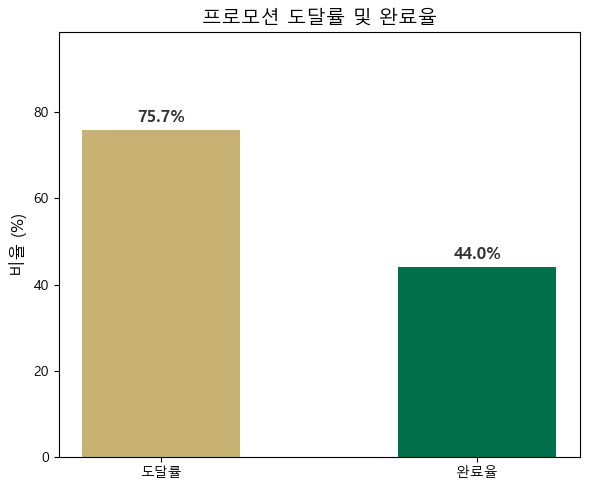

In [25]:
# ---------------------------------------------------
# ① 도달률 / 완료율 계산
# ---------------------------------------------------
viewed = df[df['event'] == 'offer viewed'].shape[0]
completed = df[df['event'] == 'offer completed'].shape[0]
received = df[df['event'] == 'offer received'].shape[0]

reach_rate = viewed / received * 100
completion_rate = completed / received * 100

# ---------------------------------------------------
# ② 시각화용 데이터 구성
# ---------------------------------------------------
labels = ['도달률', '완료율']
values = [reach_rate, completion_rate]
colors = ['#C8B273', '#00704A']  # 스타벅스 골드 & 그린

# ---------------------------------------------------
# ③ 막대 그래프 시각화
# ---------------------------------------------------
plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=colors, width=0.5)
plt.title('프로모션 도달률 및 완료율', fontsize=14)

# 막대 위에 수치 표시
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha='center', va='bottom',
        fontsize=12, fontweight='bold', color='#333333'
    )

plt.ylabel('비율 (%)', fontsize=12)
plt.ylim(0, max(values)*1.3)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_12608\1308896984.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile.groupby(['age_group', 'gender'])


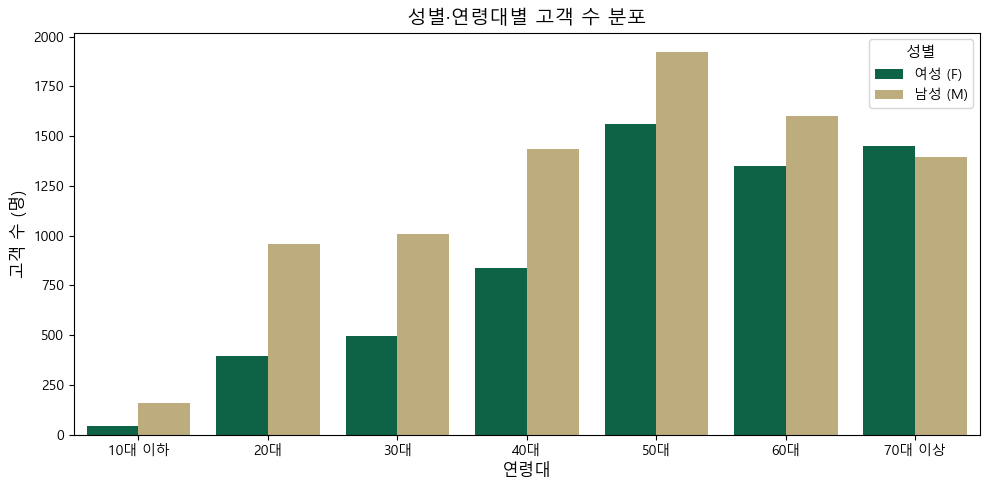

In [26]:
# ===============================
# ① 나이대 구간화 (10단위)
# ===============================
bins = [0, 19, 29, 39, 49, 59, 69, 120]
labels = ['10대 이하', '20대', '30대', '40대', '50대', '60대', '70대 이상']
profile['age_group'] = pd.cut(profile['age'], bins=bins, labels=labels, right=True)

# 성별 유효 데이터만 필터링
profile = profile[profile['gender'].isin(['M', 'F'])].copy()

# ===============================
# ② 연령대·성별별 고객 수 계산
# ===============================
age_gender_count = (
    profile.groupby(['age_group', 'gender'])
           .size()
           .reset_index(name='count')
)

# ===============================
# ③ 스타벅스 팔레트 지정
# ===============================
palette = {
    'F': '#00704A',  # Starbucks Green
    'M': '#C8B273'   # Starbucks Gold
}

# ===============================
# ④ 시각화
# ===============================
plt.figure(figsize=(10,5))
bar = sns.barplot(
    data=age_gender_count,
    x='age_group', y='count', hue='gender',
    palette=palette
)

plt.title('성별·연령대별 고객 수 분포', fontsize=14)
plt.xlabel('연령대', fontsize=12)
plt.ylabel('고객 수 (명)', fontsize=12)

# ===============================
# ⑤ 범례 색상 일치시키기
# ===============================
handles, labels = bar.get_legend_handles_labels()
plt.legend(
    handles,
    ['여성 (F)', '남성 (M)'],
    title='성별',
    fontsize=10,
    title_fontsize=11,
    loc='upper right',
    frameon=True
)

plt.tight_layout()
plt.show()

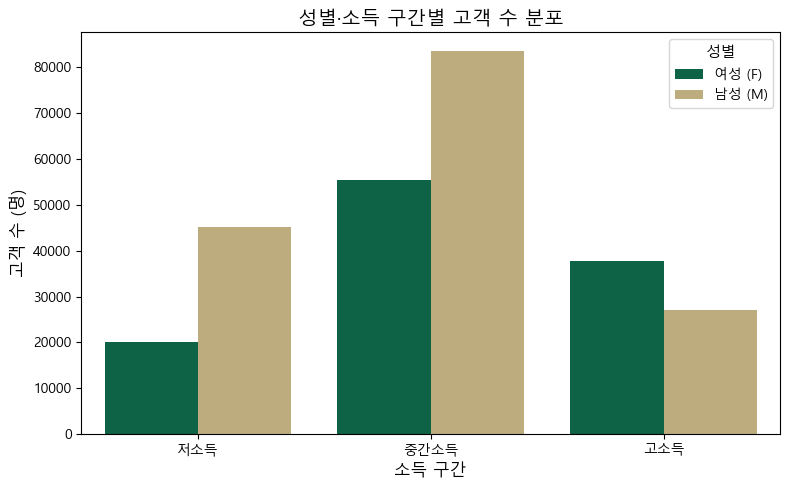

In [27]:
# ======================================================
# ① 성별 유효 데이터만 필터링
# ======================================================
tmp = df[df['gender'].isin(['M', 'F'])].copy()

# ======================================================
# ② 소득 구간(IQR 기반) 계산 (assign으로 임시 생성)
# ======================================================
Q1 = tmp['income'].quantile(0.25)
Q3 = tmp['income'].quantile(0.75)

def income_segment(x):
    if x < Q1:
        return '저소득'
    elif x > Q3:
        return '고소득'
    else:
        return '중간소득'

# assign 사용 → df 원본은 수정되지 않음
tmp2 = tmp.assign(income_segment=tmp['income'].apply(income_segment))

# ======================================================
# ③ 성별·소득 구간별 고객 수 계산
# ======================================================
income_gender_count = (
    tmp2.groupby(['income_segment', 'gender'])
        .size()
        .reset_index(name='count')
)

# 소득 구간 순서 정렬
order = ['저소득', '중간소득', '고소득']

# ======================================================
# ④ 시각화 (스타벅스 팔레트)
# ======================================================
palette = {
    'F': '#00704A',  # Starbucks Green
    'M': '#C8B273'   # Starbucks Gold
}

plt.figure(figsize=(8,5))
bar = sns.barplot(
    data=income_gender_count,
    x='income_segment', y='count', hue='gender',
    order=order, palette=palette
)

plt.title('성별·소득 구간별 고객 수 분포', fontsize=14)
plt.xlabel('소득 구간', fontsize=12)
plt.ylabel('고객 수 (명)', fontsize=12)

# ======================================================
# 범례 색상 일치
# ======================================================
handles, labels = bar.get_legend_handles_labels()
plt.legend(
    handles,
    ['여성 (F)', '남성 (M)'],
    title='성별',
    fontsize=10,
    title_fontsize=11,
    loc='upper right',
    frameon=True
)

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_12608\1699916978.py:43: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  bar = sns.barplot(


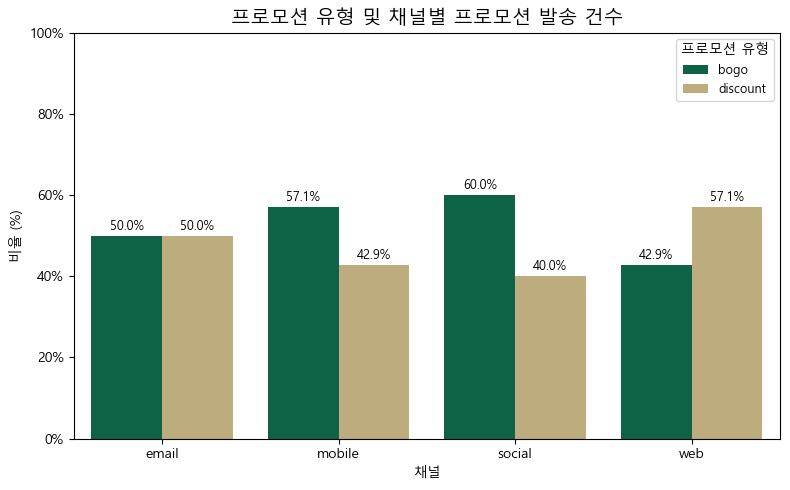

In [28]:
# =============================================
# ① offer received 기준 필터링
# =============================================
received_df = df[df['event'] == 'offer received'].copy()

# 각 offer_id별 채널 정보 (email/mobile/social/web) 가져오기
channel_info = (
    received_df[['offer_id', 'offer_type', 'email', 'mobile', 'social', 'web']]
      .drop_duplicates('offer_id')
)

# =============================================
# ② melt로 채널별 구조로 변환
# =============================================
melted = channel_info.melt(
    id_vars=['offer_id', 'offer_type'],
    value_vars=['email', 'mobile', 'social', 'web'],
    var_name='channel', value_name='is_used'
)

# True인 채널만 남기기
melted = melted[(melted['is_used'] == True) & (melted['offer_type'] != 'informational')]

# =============================================
# ③ 채널별 Offer Type 노출 횟수 계산
# =============================================
channel_offer_counts = (
    melted.groupby(['channel', 'offer_type'])
           .size()
           .reset_index(name='count')
)

# 전체 합 대비 각 채널 내부 비율
channel_offer_counts['ratio'] = (
    channel_offer_counts.groupby('channel')['count']
                        .transform(lambda x: x / x.sum())
)

# =============================================
# ④ 시각화
# =============================================
plt.figure(figsize=(8,5))
bar = sns.barplot(
    data=channel_offer_counts,
    x='channel', y='ratio', hue='offer_type',
    palette=['#00704A', '#C8B273', '#4B2E05']
)

plt.title('프로모션 유형 및 채널별 프로모션 발송 건수', fontsize=14)
plt.xlabel('채널')
plt.ylabel('비율 (%)')
plt.ylim(0, 1)
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

# 퍼센티지 라벨
for p in bar.patches:
    h = p.get_height()
    if pd.notna(h) and h > 0:
        bar.annotate(f'{h*100:.1f}%',
                     (p.get_x()+p.get_width()/2, h),
                     ha='center', va='bottom', fontsize=9, color='black', xytext=(0,2),
                     textcoords='offset points')

plt.legend(title='프로모션 유형', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()

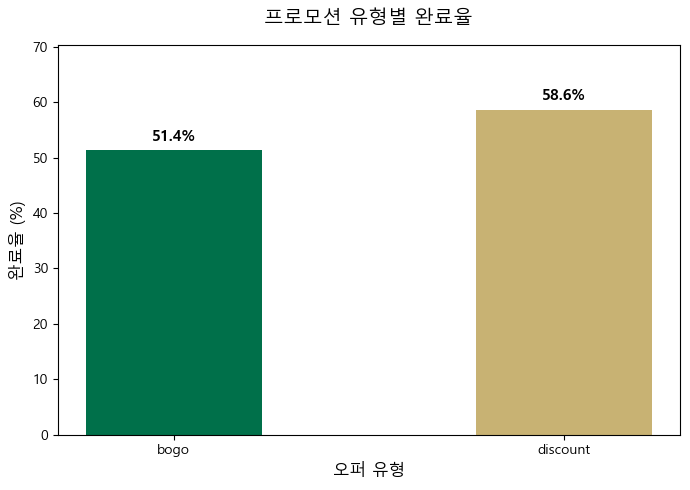

In [29]:
# ===============================================
# ① 이벤트별 오퍼 집계 (offer received vs offer completed)
# ===============================================
rate_by_offer = (
    df[df['event'].isin(['offer received', 'offer completed'])]
    .groupby(['offer_type', 'event'])
    .size()
    .unstack(fill_value=0)
    .assign(participation_rate=lambda x: x['offer completed'] / x['offer received'] * 100)
    .reset_index()
)

# ===============================================
# ② informational 제외
# ===============================================
rate_by_offer_filtered = rate_by_offer[rate_by_offer['offer_type'] != 'informational']

# ===============================================
# ③ 시각화 (스타벅스 테마)
# ===============================================
colors = ['#00704A', '#C8B273', '#4B2E05'][:len(rate_by_offer_filtered)]

plt.figure(figsize=(7,5))
bars = plt.bar(
    rate_by_offer_filtered['offer_type'],
    rate_by_offer_filtered['participation_rate'],
    color=colors,
    width=0.45
)

# ===============================================
# ④ 막대 위에 퍼센티지 표시
# ===============================================
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# ===============================================
# ⑤ 그래프 서식
# ===============================================
plt.title('프로모션 유형별 완료율', fontsize=14, pad=15)
plt.xlabel('오퍼 유형', fontsize=12)
plt.ylabel('완료율 (%)', fontsize=12)
plt.ylim(0, rate_by_offer_filtered['participation_rate'].max() * 1.2)
plt.tight_layout()
plt.show()

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306534 non-null  object 
 1   event             306534 non-null  object 
 2   value             306534 non-null  object 
 3   time              306534 non-null  int64  
 4   reward_value      33579 non-null   float64
 5   amount            138953 non-null  float64
 6   offer_id          167581 non-null  object 
 7   gender            272762 non-null  object 
 8   age               272762 non-null  float64
 9   id_x              272762 non-null  object 
 10  became_member_on  272762 non-null  object 
 11  income            272762 non-null  float64
 12  reward_port       167581 non-null  float64
 13  difficulty        167581 non-null  float64
 14  duration          167581 non-null  float64
 15  offer_type        167581 non-null  object 
 16  id_y              16

# =====================================
# 통계 분석 시작
# =====================================

# 완료율
# ========================

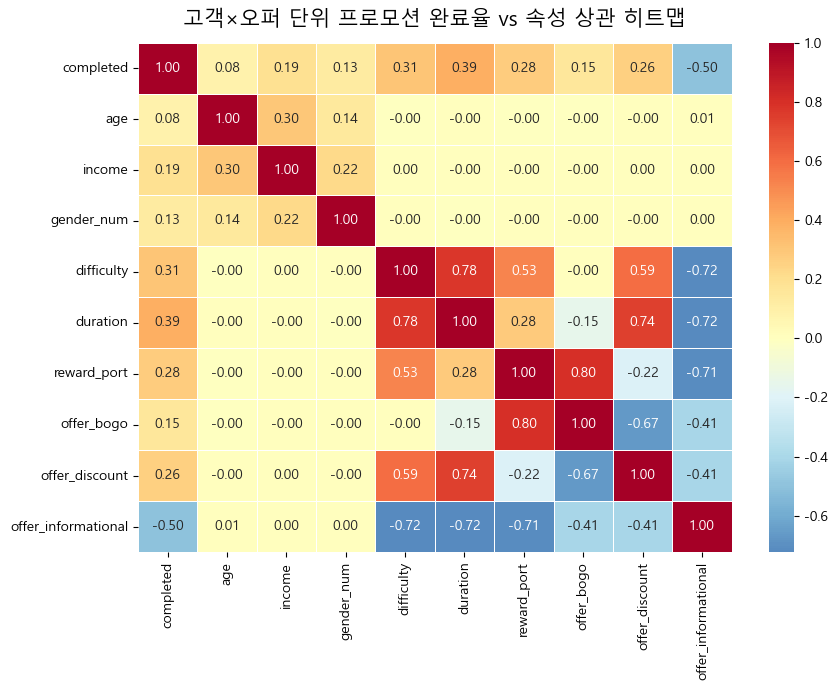


 완료율과 상관 높은 변수 TOP 3
duration       0.391019
difficulty     0.310443
reward_port    0.279156
Name: completed, dtype: float64

 해석 가이드:
 - duration: 양의 상관(+), 완료율과의 상관 0.39
 - difficulty: 양의 상관(+), 완료율과의 상관 0.31
 - reward_port: 양의 상관(+), 완료율과의 상관 0.28

 transcript, profile, portfolio 컬럼 그대로 유지됨: False


In [31]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ===============================
# ② 완료여부 계산 (r→v→c + r→c)
# ===============================
evt = (
    transcript['event'].astype(str).str.strip().str.lower()
      .replace({'offer recieved':'offer received', 'received':'offer received', 'viewed':'offer viewed'})
)
ev = transcript.assign(event_norm=evt)
ev = ev[ev['event_norm'].isin(['offer received','offer viewed','offer completed'])].copy()

order = {'offer received':0, 'offer viewed':1, 'offer completed':2}
ev['_ord'] = ev['event_norm'].map(order)
ev = ev.sort_values(['person','offer_id','time','_ord'], kind='mergesort')

T_MAX = 714.0
completion_flags = []
for (person, offer_id), g in ev.groupby(['person','offer_id'], dropna=False):
    rec_q, view_q = [], []
    completed_flag = 0
    for _, row in g.iterrows():
        e, t = row['event_norm'], row['time']
        if e == 'offer received':
            rec_q.append(t)
        elif e == 'offer viewed':
            idx = next((i for i, rt in enumerate(rec_q) if rt <= t), None)
            if idx is not None:
                recv_t = rec_q.pop(idx)
                view_q.append((t, recv_t))
        elif e == 'offer completed':
            idx = next((i for i, (vt, _) in enumerate(view_q) if vt <= t), None)
            if idx is not None:
                vt, recv_t = view_q.pop(idx)
                if 0 <= t - recv_t <= T_MAX:
                    completed_flag = 1
                    break
            else:
                idx_direct = next((i for i, rt in enumerate(rec_q) if rt <= t), None)
                if idx_direct is not None:
                    recv_t = rec_q.pop(idx_direct)
                    if 0 <= t - recv_t <= T_MAX:
                        completed_flag = 1
                        break
    completion_flags.append({'person': person, 'offer_id': offer_id, 'completed': completed_flag})

df_completed = pd.DataFrame(completion_flags)

# ===============================
# ③ 고객×오퍼 단위 병합 (중복 제거)
# ===============================
profile_ren   = profile.rename(columns={'id':'profile_id'})
portfolio_ren = portfolio.rename(columns={'id':'portfolio_id'})


merged_tmp = (
    df_completed
      .merge(profile_ren[['profile_id','gender','age','income']],
             left_on='person', right_on='profile_id', how='left')
      .merge(portfolio_ren[['portfolio_id','offer_type','difficulty','duration','reward_port']],
             left_on='offer_id', right_on='portfolio_id', how='left')
)

# ===============================
# ④ 인코딩 + 수치형 변환
# ===============================
merged_tmp['gender_num'] = merged_tmp['gender'].map({'M':0, 'F':1, 'O':np.nan})
merged_tmp = pd.get_dummies(merged_tmp, columns=['offer_type'], prefix='offer', dtype=float)

for c in ['completed','age','income','difficulty','duration',
          'reward_port','gender_num','offer_bogo','offer_discount','offer_informational']:
    if c not in merged_tmp.columns:
        merged_tmp[c] = np.nan
    merged_tmp[c] = pd.to_numeric(merged_tmp[c], errors='coerce')

# ===============================
# ⑤ 상관 분석 (고객×오퍼 기준)
# ===============================
cols = ['completed','age','income','gender_num','difficulty','duration',
        'reward_port','offer_bogo','offer_discount','offer_informational']
data = merged_tmp[cols].dropna()

corr = data.corr(method='spearman')

# ===============================
# ⑥ 히트맵 (한 장)
# ===============================
# --------------------------------------------------
# 변수 한글 매핑
# --------------------------------------------------

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap='RdYlBu_r', center=0, fmt=".2f", linewidths=.5)
plt.title('고객×오퍼 단위 프로모션 완료율 vs 속성 상관 히트맵', fontsize=15, pad=12)
plt.tight_layout()
plt.show()
top_corr = corr['completed'].drop('completed').sort_values(ascending=False)
print("\n 완료율과 상관 높은 변수 TOP 3")
print(top_corr.head(3))

print("\n 해석 가이드:")
for var, val in top_corr.head(3).items():
    direction = "양의 상관(+)" if val > 0 else "음의 상관(-)"
    print(f" - {var}: {direction}, 완료율과의 상관 {val:.2f}")

# 확인용: 원본은 건드리지 않음
print("\n transcript, profile, portfolio 컬럼 그대로 유지됨:", set(['completed']).issubset(transcript.columns))


In [32]:
# ====================================================================
# ① 전제: 완료율 큐 매칭 결과 df_completed (person, offer_id, completed)
# ====================================================================
# transcript / profile / portfolio는 원본 그대로 사용
# 이 셋은 이미 메모리에 로드돼 있다고 가정

profile_ren = profile.rename(columns={'id': 'profile_id'})
portfolio_ren = portfolio.rename(columns={'id': 'portfolio_id'})

# 병합: 분석용 임시테이블 생성 (원본 수정 X)
merged_tmp = (
    transcript.merge(df_completed, on=['person','offer_id'], how='left')
              .merge(profile_ren[['profile_id','gender','age','income']],
                     left_on='person', right_on='profile_id', how='left')
              .merge(portfolio_ren[['portfolio_id','offer_type','difficulty','duration','reward_port']],
                     left_on='offer_id', right_on='portfolio_id', how='left')
)

merged_tmp['completed'] = merged_tmp['completed'].fillna(0).astype(int)

# ====================================================================
# ② 분석용 변수 세트 구성
# ====================================================================
cols = ['completed', 'duration', 'reward_port', 'difficulty']
df_model = merged_tmp[cols].dropna().copy()

# ====================================================================
# ③ 독립변수(X) / 종속변수(y)
# ====================================================================
X = sm.add_constant(df_model[['duration', 'reward_port', 'difficulty']])
y = df_model['completed']

# ====================================================================
# ④ 로지스틱 회귀 적합
# ====================================================================
model = sm.Logit(y, X).fit()

# ====================================================================
# ⑤ 결과 요약 테이블
# ====================================================================
result_table = pd.DataFrame({
    '변수': model.params.index,
    'coef': model.params.values,
    'odds_ratio': np.exp(model.params.values),
    'p_value': model.pvalues.values
}).round(4)

print("="*70)
print(" [로지스틱 회귀 결과: duration / reward / difficulty]")
print("="*70)
print(result_table)
print("="*70)

# ====================================================================
# ⑥ 변수별 자동 해석
# ====================================================================
print("\n💬 [해석 자동 요약]\n")

for i, row in result_table.iterrows():
    var = row['변수']
    if var == 'const':
        continue  # 상수항 제외
    
    coef = row['coef']
    odds = row['odds_ratio']
    pval = row['p_value']

    # 방향성
    if coef > 0:
        direction = " 양의 영향 (값이 클수록 완료율 ↑)"
    else:
        direction = " 음의 영향 (값이 클수록 완료율 ↓)"

    # 유의성
    if pval < 0.05:
        sig = "유의함 (p < 0.05)"
    else:
        sig = "통계적으로 유의하지 않음"

    print(f" [{var}]")
    print(f" ├ 회귀계수(coef): {coef:.4f}")
    print(f" ├ 오즈비(odds_ratio): {odds:.2f}")
    print(f" ├ 유의수준(p-value): {pval:.4f} → {sig}")
    print(f" └ 해석: {direction}")
    print("-"*70)

# ====================================================================
# ⑦ 모델 요약
# ====================================================================
print("\n [모델 적합 요약]")
print(f"총 관측치 수: {len(df_model):,}")
print(f"로그우도(Log-Likelihood): {model.llf:.2f}")
print(f"모형 유의성 검정(pseudo R²): {model.prsquared:.3f}")

# ====================================================================
# ⑧ 원본 확인 (안전성 체크)
# ====================================================================
print("\n 원본 변경 여부 확인:")
print("transcript에 'completed' 존재? →", 'completed' in transcript.columns)

Optimization terminated successfully.
         Current function value: 0.583822
         Iterations 5
 [로지스틱 회귀 결과: duration / reward / difficulty]
            변수    coef  odds_ratio  p_value
0        const -3.2634      0.0383      0.0
1     duration  0.5564      1.7443      0.0
2  reward_port  0.1575      1.1706      0.0
3   difficulty -0.0888      0.9150      0.0

💬 [해석 자동 요약]

 [duration]
 ├ 회귀계수(coef): 0.5564
 ├ 오즈비(odds_ratio): 1.74
 ├ 유의수준(p-value): 0.0000 → 유의함 (p < 0.05)
 └ 해석:  양의 영향 (값이 클수록 완료율 ↑)
----------------------------------------------------------------------
 [reward_port]
 ├ 회귀계수(coef): 0.1575
 ├ 오즈비(odds_ratio): 1.17
 ├ 유의수준(p-value): 0.0000 → 유의함 (p < 0.05)
 └ 해석:  양의 영향 (값이 클수록 완료율 ↑)
----------------------------------------------------------------------
 [difficulty]
 ├ 회귀계수(coef): -0.0888
 ├ 오즈비(odds_ratio): 0.92
 ├ 유의수준(p-value): 0.0000 → 유의함 (p < 0.05)
 └ 해석:  음의 영향 (값이 클수록 완료율 ↓)
----------------------------------------------------------------------

 [모델 적합

C:\Users\User\AppData\Local\Temp\ipykernel_12608\852123928.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


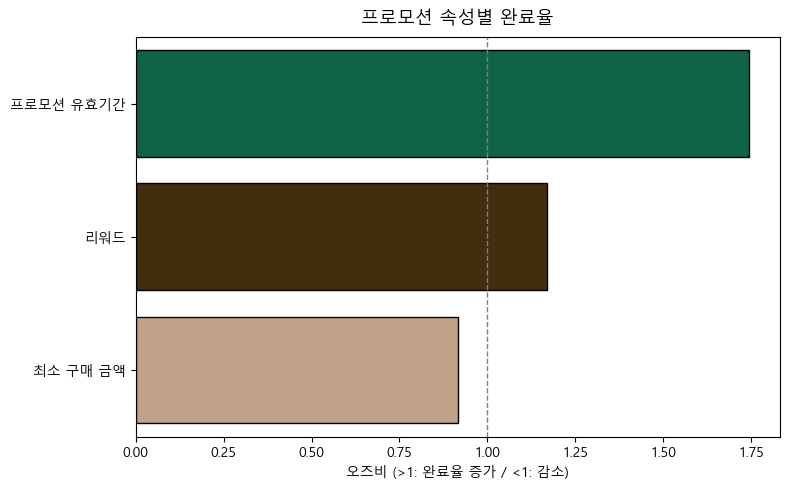


원본 데이터 안전성 확인:
transcript에 'completed' 컬럼 존재? → False


In [33]:
# --------------------------------------------------
# 변수 한글 매핑
# --------------------------------------------------
label_map = {
    'duration': '프로모션 유효기간',
    'difficulty': '최소 구매 금액',
    'reward_port': '리워드'
}
viz_df = result_table[result_table['변수'] != 'const'].copy()
viz_df['변수'] = viz_df['변수'].replace(label_map)  # :흰색_확인_표시: Y축 표시명 교체
# --------------------------------------------------
# 색상 매핑
# --------------------------------------------------
color_map = {
    '프로모션 유효기간': '#00704A',     # 스타벅스 그린
    '최소 구매 금액': '#C8A27E',        # 라떼 베이지
    '리워드': '#4B2E05'                # 다크 브라운
}
# --------------------------------------------------
# 시각화
# --------------------------------------------------
plt.figure(figsize=(8,5))
sns.barplot(
    data=viz_df,
    x='odds_ratio',
    y='변수',
    palette=color_map,
    edgecolor='black'
)
plt.axvline(1, color='gray', linestyle='--', linewidth=1)
plt.title('프로모션 속성별 완료율', fontsize=13, pad=10)
plt.xlabel('오즈비 (>1: 완료율 증가 / <1: 감소)')
plt.ylabel('')
plt.tight_layout()
plt.show()
# --------------------------------------------------
# 원본 데이터 안전성 체크
# --------------------------------------------------
print("\n원본 데이터 안전성 확인:")
print("transcript에 'completed' 컬럼 존재? →", 'completed' in transcript.columns)

# ========================
# 이탈률
# ========================

In [34]:
# ===========이탈률==================
# =====================================================
# 이탈률 분석 (r→v→c + r→c 포함)
# =====================================================
from collections import defaultdict

print("=" * 70)
print("프로모션별 반응 패턴 및 이탈률 분석 (viewed 생략 케이스 포함)")
print("=" * 70)
# -----------------------------------------------------
# :일: 이벤트 표준화 및 필터링
# -----------------------------------------------------
evt = (
    df['event'].astype(str).str.strip().str.lower()
      .replace({
          'offer recieved': 'offer received',
          'received': 'offer received',
          'viewed': 'offer viewed'
      })
)
ev = df.assign(event_norm=evt)
ev = ev[ev['event_norm'].isin(['offer received', 'offer viewed', 'offer completed'])].copy()
# 정렬
order = {'offer received': 0, 'offer viewed': 1, 'offer completed': 2}
ev['_ord'] = ev['event_norm'].map(order)
ev = ev.sort_values(['person', 'offer_id', 'time', '_ord'], kind='mergesort')
print(f"\n[원본 데이터]")
print(f"Received 이벤트: {(ev['event_norm'] == 'offer received').sum():,}건")
print(f"Viewed 이벤트: {(ev['event_norm'] == 'offer viewed').sum():,}건")
print(f"Completed 이벤트: {(ev['event_norm'] == 'offer completed').sum():,}건")
# -----------------------------------------------------
# :둘: 큐 방식 매칭 (r→v→c + r→c)
# -----------------------------------------------------
T_MAX = 714.0
results = []
for (person, offer_id), g in ev.groupby(['person', 'offer_id'], dropna=False):
    rec_q = []   # 소비되지 않은 received 시간들
    view_q = []  # (view_time, matched_received_time)
    offer_type = g['offer_type'].iloc[0] if 'offer_type' in g.columns else None
    for _, row in g.iterrows():
        e = row['event_norm']
        t = row['time']
        if e == 'offer received':
            rec_q.append(t)
            results.append({
                'person': person,
                'offer_id': offer_id,
                'offer_type': offer_type,
                'received_time': t,
                'viewed_time': None,
                'completed_time': None,
                'response_type': '무반응',
                'completion_path': None
            })
        elif e == 'offer viewed':
            idx = next((i for i, rt in enumerate(rec_q) if rt <= t), None)
            if idx is not None:
                recv_t = rec_q.pop(idx)
                view_q.append((t, recv_t))
                for rec in reversed(results):
                    if (rec['person'] == person and
                        rec['offer_id'] == offer_id and
                        rec['received_time'] == recv_t and
                        rec['viewed_time'] is None):
                        rec['viewed_time'] = t
                        rec['response_type'] = '중도이탈'
                        break
        elif e == 'offer completed':
            # 1순위: r→v→c
            idx = next((i for i, (vt, _) in enumerate(view_q) if vt <= t), None)
            if idx is not None:
                vt, recv_t = view_q.pop(idx)
                total_time = t - recv_t
                is_valid = (0 <= total_time <= T_MAX)
                for rec in reversed(results):
                    if (rec['person'] == person and
                        rec['offer_id'] == offer_id and
                        rec['received_time'] == recv_t and
                        rec['viewed_time'] == vt):
                        rec['completed_time'] = t
                        rec['response_type'] = '완료' if is_valid else '무효완료'
                        rec['completion_path'] = 'r→v→c'
                        break
            else:
                # 2순위: r→c
                idx_direct = next((i for i, rt in enumerate(rec_q) if rt <= t), None)
                if idx_direct is not None:
                    recv_t = rec_q.pop(idx_direct)
                    total_time = t - recv_t
                    is_valid = (0 <= total_time <= T_MAX)
                    for rec in reversed(results):
                        if (rec['person'] == person and
                            rec['offer_id'] == offer_id and
                            rec['received_time'] == recv_t and
                            rec['completed_time'] is None):
                            rec['completed_time'] = t
                            rec['response_type'] = '완료(직접)' if is_valid else '무효완료'
                            rec['completion_path'] = 'r→c'
                            break
# -----------------------------------------------------
# :셋: DataFrame 생성
# -----------------------------------------------------
base = pd.DataFrame(results)
print(f"\n[프로모션 발송 단위 데이터]")
print(f"총 프로모션 발송(received): {len(base):,}건")
# -----------------------------------------------------
# :넷: 전체 반응 패턴 분포
# -----------------------------------------------------
print("\n" + "=" * 70)
print("전체 반응 패턴 분포")
print("=" * 70)
print(base['response_type'].value_counts())
print(f"\n완료 경로 분포:")
print(base[base['completion_path'].notna()]['completion_path'].value_counts())
# -----------------------------------------------------
# :다섯: 전체 이탈률 계산
# -----------------------------------------------------
total_received = len(base)
response_counts = base['response_type'].value_counts()
completed_count = response_counts.get('완료', 0) + response_counts.get('완료(직접)', 0)
dropout_count = response_counts.get('중도이탈', 0)
no_response_count = response_counts.get('무반응', 0)
churn_count = dropout_count + no_response_count
churn_rate = (churn_count / total_received) * 100
completion_rate = (completed_count / total_received) * 100
print("\n" + "=" * 70)
print("전체 이탈률")
print("=" * 70)
print(f"완료(r→v→c): {response_counts.get('완료', 0):,}건")
print(f"완료(r→c, viewed 생략): {response_counts.get('완료(직접)', 0):,}건")
print(f"총 완료: {completed_count:,}건 ({completion_rate:.2f}%)")
print(f"중도이탈(viewed만): {dropout_count:,}건 ({dropout_count/total_received*100:.2f}%)")
print(f"무반응(received만): {no_response_count:,}건 ({no_response_count/total_received*100:.2f}%)")
print(f"총 이탈: {churn_count:,}건 ({churn_rate:.2f}%)")
# -----------------------------------------------------
# :여섯: Offer Type별 이탈률 분석
# -----------------------------------------------------
print("\n" + "=" * 70)
print("Offer Type별 이탈률")
print("=" * 70)
type_analysis = base.groupby('offer_type').agg(
    total_sent=('response_type', 'count'),
    완료_rvc=('response_type', lambda x: (x == '완료').sum()),
    완료_rc=('response_type', lambda x: (x == '완료(직접)').sum()),
    중도이탈=('response_type', lambda x: (x == '중도이탈').sum()),
    무반응=('response_type', lambda x: (x == '무반응').sum())
).reset_index()
type_analysis['총_완료'] = type_analysis['완료_rvc'] + type_analysis['완료_rc']
type_analysis['총_이탈'] = type_analysis['중도이탈'] + type_analysis['무반응']
type_analysis['이탈률(%)'] = (type_analysis['총_이탈'] / type_analysis['total_sent'] * 100).round(2)
type_analysis['완료율(%)'] = (type_analysis['총_완료'] / type_analysis['total_sent'] * 100).round(2)
print(type_analysis.to_string(index=False))
# -----------------------------------------------------
# :일곱: 결과 반환
# -----------------------------------------------------
base.head()

프로모션별 반응 패턴 및 이탈률 분석 (viewed 생략 케이스 포함)

[원본 데이터]
Received 이벤트: 76,277건
Viewed 이벤트: 57,725건
Completed 이벤트: 33,579건

[프로모션 발송 단위 데이터]
총 프로모션 발송(received): 76,277건

전체 반응 패턴 분포
response_type
중도이탈      29874
완료        23788
무반응       12824
완료(직접)     9791
Name: count, dtype: int64

완료 경로 분포:
completion_path
r→v→c    23788
r→c       9791
Name: count, dtype: int64

전체 이탈률
완료(r→v→c): 23,788건
완료(r→c, viewed 생략): 9,791건
총 완료: 33,579건 (44.02%)
중도이탈(viewed만): 29,874건 (39.17%)
무반응(received만): 12,824건 (16.81%)
총 이탈: 42,698건 (55.98%)

Offer Type별 이탈률
   offer_type  total_sent  완료_rvc  완료_rc  중도이탈  무반응  총_완료  총_이탈  이탈률(%)  완료율(%)
         bogo       30499   11196   4473 12026 2804 15669 14830   48.62   51.38
     discount       30543   12592   5318  7017 5616 17910 12633   41.36   58.64
informational       15235       0      0 10831 4404     0 15235  100.00    0.00


,person,offer_id,offer_type,received_time,viewed_time,completed_time,response_type,completion_path
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,576,NaN,576.0,완료(직접),r→c
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,336,372.0,NaN,중도이탈,None
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,168,192.0,NaN,중도이탈,None
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,408,NaN,414.0,완료(직접),r→c
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,504,NaN,528.0,완료(직접),r→c


In [35]:
import statsmodels.api as sm

base['churned'] = (~base['response_type'].isin(['완료', '완료(직접)'])).astype(int)
# -----------------------------------------------------
# ⑥ profile + portfolio 병합
# -----------------------------------------------------
merged = (
    base
    .merge(portfolio[['id','offer_type','difficulty','duration','reward_port']],
           left_on='offer_id', right_on='id', how='left')
    .merge(profile[['id','age','income','gender']],
           left_on='person', right_on='id', how='left')
)
# -----------------------------------------------------
# ⑦ 로지스틱 회귀 (핵심 3요인)
# -----------------------------------------------------
selected = ['duration', 'difficulty', 'reward_port']
subset = merged[['churned'] + selected].dropna()
X = sm.add_constant(subset[selected])
y = subset['churned']
model = sm.GLM(y, X, family=sm.families.Binomial())
result = model.fit()
odds = pd.DataFrame({
    '변수': result.params.index,
    '회귀계수(coef)': result.params.values,
    '오즈비(odds_ratio)': np.exp(result.params.values),
    'p_value': result.pvalues
}).round(4)
print("\n[3개 변수 중심 로지스틱 회귀 결과]")
print(odds)
# -----------------------------------------------------
# ⑧ 자동 해석 요약
# -----------------------------------------------------
print("\n[해석 요약]")
for _, r in odds.iterrows():
    if r['변수'] == 'const':
        continue
    direction = "이탈률 증가" if r['회귀계수(coef)'] > 0 else "이탈률 감소"
    signif = "유의함" if r['p_value'] < 0.05 else "비유의"
    print(f":앞쪽_화살표: {r['변수']}: {direction} ({signif}) | 오즈비={r['오즈비(odds_ratio)']:.2f}")

print('='*80)
print(f"로그 우도 : {result.llf:.4f}")
print(f"Null 모델 로그 우도 (Log-L. Null): {result.llnull:.4f}")

import statsmodels.api as sm
# Logit 클래스 사용
model = sm.Logit(y, X) 
result = model.fit()
# result는 LogitResults 객체이므로 .prsquared 속성을 사용할 수 있음
print(f"모형 유의성 (Pseudo R²): {result.prsquared:.4f}")
print('='*80)
print(r['p_value'])


[3개 변수 중심 로지스틱 회귀 결과]
                      변수  회귀계수(coef)  오즈비(odds_ratio)  p_value
const              const      3.5883          36.1718      0.0
duration        duration     -0.5309           0.5881      0.0
difficulty    difficulty      0.1081           1.1142      0.0
reward_port  reward_port     -0.1583           0.8536      0.0

[해석 요약]
:앞쪽_화살표: duration: 이탈률 감소 (유의함) | 오즈비=0.59
:앞쪽_화살표: difficulty: 이탈률 증가 (유의함) | 오즈비=1.11
:앞쪽_화살표: reward_port: 이탈률 감소 (유의함) | 오즈비=0.85
로그 우도 : -46408.9003
Null 모델 로그 우도 (Log-L. Null): -52324.7883
Optimization terminated successfully.
         Current function value: 0.608426
         Iterations 5
모형 유의성 (Pseudo R²): 0.1131
0.0



[해석 요약]
:앞쪽_화살표: 프로모션 유효기간: 이탈률 감소 (유의함) | 오즈비=0.59
:앞쪽_화살표: 최소 구매 금액: 이탈률 증가 (유의함) | 오즈비=1.11
:앞쪽_화살표: 리워드 금액: 이탈률 감소 (유의함) | 오즈비=0.85


C:\Users\User\AppData\Local\Temp\ipykernel_12608\2134788736.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


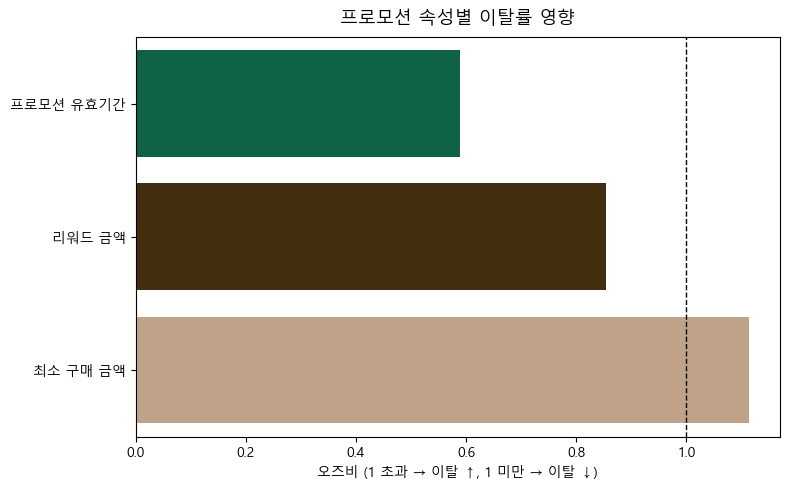

In [36]:
# -----------------------------------------------------
# ⑨ 시각화
# -----------------------------------------------------

label_map = {
    'duration': '프로모션 유효기간',
    'difficulty': '최소 구매 금액',
    'reward_port': '리워드 금액'
}
odds['변수'] = odds['변수'].replace(label_map)
# --------------------------------------------------
# ⑤ 간단 해석문 자동 출력
# --------------------------------------------------
print("\n[해석 요약]")
for _, r in odds.iterrows():
    if r['변수'] == 'const':
        continue
    direction = "이탈률 증가" if r['회귀계수(coef)'] > 0 else "이탈률 감소"
    signif = "유의함" if r['p_value'] < 0.05 else "비유의"
    print(f":앞쪽_화살표: {r['변수']}: {direction} ({signif}) | 오즈비={r['오즈비(odds_ratio)']:.2f}")
    
# --------------------------------------------------
# ⑥ 시각화
# --------------------------------------------------
# 원하는 순서 정의
custom_order = ['프로모션 유효기간', '리워드 금액', '최소 구매 금액']

# const를 제외하고 원하는 순서대로 데이터프레임 정렬
plot_data = odds[odds['변수']!='const'].set_index('변수').loc[custom_order].reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=plot_data, # 정렬된 데이터 사용
    x='오즈비(odds_ratio)',
    y='변수',
    palette=['#00704A', '#4B2E05', '#C8A27E'] # (필요에 따라 팔레트 순서도 조정 가능)
)
plt.axvline(1, color='black', linestyle='--', lw=1)
plt.title('프로모션 속성별 이탈률 영향', fontsize=13, pad=10)
plt.xlabel('오즈비 (1 초과 → 이탈 ↑, 1 미만 → 이탈 ↓)')
plt.ylabel('')
plt.tight_layout()
plt.show()

# ========================
# 반응시간
# ========================

In [37]:
# 반응 소요시간 분석 (r→v→c + r→c 포함)
# =====================================================

print("=" * 70)
print("프로모션별 반응시간 분석 - viewed 생략 케이스 포함")
print("=" * 70)
# -----------------------------------------------------
# :일: 이벤트 표준화 및 필터링
# -----------------------------------------------------
evt = (
    df['event'].astype(str).str.strip().str.lower()
      .replace({
          'offer recieved': 'offer received',
          'received': 'offer received',
          'viewed': 'offer viewed'
      })
)
ev = df.assign(event_norm=evt)
ev = ev[ev['event_norm'].isin(['offer received', 'offer viewed', 'offer completed'])].copy()
# -----------------------------------------------------
# :둘: 정렬
# -----------------------------------------------------
order = {'offer received': 0, 'offer viewed': 1, 'offer completed': 2}
ev['_ord'] = ev['event_norm'].map(order)
ev = ev.sort_values(['person', 'offer_id', 'time', '_ord'], kind='mergesort')
T_MAX = 714.0  # 최대 반응시간 제한
records = []
# -----------------------------------------------------
# :셋: person, offer_id별 그룹화
# -----------------------------------------------------
for (person, offer_id), g in ev.groupby(['person', 'offer_id'], dropna=False):
    rec_q = []
    view_q = []
    for _, row in g.iterrows():
        e = row['event_norm']
        t = row['time']
        if e == 'offer received':
            rec_q.append(t)
            records.append({
                'person': person,
                'offer_id': offer_id,
                'received_time': t,
                'viewed_time': None,
                'completed_time': None,
                'reaction2': None,  # viewed - received
                'reaction1': None,  # completed - viewed
                'total_time': None,
                'completion_path': None,  # 'r→v→c' or 'r→c'
                'is_valid': None
            })
        elif e == 'offer viewed':
            idx = next((i for i, rt in enumerate(rec_q) if rt <= t), None)
            if idx is not None:
                recv_t = rec_q.pop(idx)
                reaction2 = t - recv_t
                view_q.append((t, recv_t))
                for rec in reversed(records):
                    if (rec['person'] == person and
                        rec['offer_id'] == offer_id and
                        rec['received_time'] == recv_t and
                        rec['viewed_time'] is None):
                        rec['viewed_time'] = t
                        rec['reaction2'] = reaction2
                        break
        elif e == 'offer completed':
            # 1순위: r→v→c
            idx = next((i for i, (vt, _) in enumerate(view_q) if vt <= t), None)
            if idx is not None:
                vt, recv_t = view_q.pop(idx)
                reaction2 = vt - recv_t
                reaction1 = t - vt
                total_time = t - recv_t
                is_valid = (0 <= reaction2 <= T_MAX and
                            0 <= reaction1 <= T_MAX and
                            0 <= total_time <= T_MAX)
                for rec in reversed(records):
                    if (rec['person'] == person and
                        rec['offer_id'] == offer_id and
                        rec['received_time'] == recv_t and
                        rec['viewed_time'] == vt):
                        rec['completed_time'] = t
                        rec['reaction1'] = reaction1
                        rec['total_time'] = total_time
                        rec['completion_path'] = 'r→v→c'
                        rec['is_valid'] = is_valid
                        break
            else:
                # 2순위: r→c (viewed 생략)
                idx_direct = next((i for i, rt in enumerate(rec_q) if rt <= t), None)
                if idx_direct is not None:
                    recv_t = rec_q.pop(idx_direct)
                    total_time = t - recv_t
                    is_valid = (0 <= total_time <= T_MAX)
                    for rec in reversed(records):
                        if (rec['person'] == person and
                            rec['offer_id'] == offer_id and
                            rec['received_time'] == recv_t and
                            rec['completed_time'] is None):
                            rec['completed_time'] = t
                            rec['reaction1'] = None
                            rec['reaction2'] = None
                            rec['total_time'] = total_time
                            rec['completion_path'] = 'r→c'
                            rec['is_valid'] = is_valid
                            break
# -----------------------------------------------------
# :넷: DataFrame 생성 및 분류
# -----------------------------------------------------
reaction_df = pd.DataFrame(records)
def classify_response(row):
    if row['is_valid'] is True:
        if row['completion_path'] == 'r→v→c':
            return '완료'
        else:
            return '완료(직접)'
    elif row['viewed_time'] is not None:
        return '중도이탈'
    else:
        return '무반응'
reaction_df['response_type'] = reaction_df.apply(classify_response, axis=1)
# -----------------------------------------------------
# :다섯: 결과 요약 출력
# -----------------------------------------------------
print(f"\n전체 프로모션 발송(received): {len(reaction_df):,}건")
print("\n반응 유형 분포:")
print(reaction_df['response_type'].value_counts())
print("\n완료 경로 분포:")
completed = reaction_df[reaction_df['is_valid'] == True]
if len(completed) > 0:
    print(completed['completion_path'].value_counts())
    print(f"\n총 유효 완료: {len(completed):,}건")
    print(f"  ├─ r→v→c: {(completed['completion_path']=='r→v→c').sum():,}건")
    print(f"  └─ r→c: {(completed['completion_path']=='r→c').sum():,}건")
print("\n반응시간 통계 (유효 완료만):")
if len(completed) > 0:
    print(f"전체 평균: {completed['total_time'].mean():.2f}시간")
    print(f"전체 중앙: {completed['total_time'].median():.2f}시간")
    rvc = completed[completed['completion_path'] == 'r→v→c']
    rc = completed[completed['completion_path'] == 'r→c']
    if len(rvc) > 0:
        print("\nr→v→c 경로:")
        print(f"  평균: {rvc['total_time'].mean():.2f}시간")
        print(f"  중앙: {rvc['total_time'].median():.2f}시간")
        print(f"  reaction2 평균: {rvc['reaction2'].mean():.2f}시간")
        print(f"  reaction1 평균: {rvc['reaction1'].mean():.2f}시간")
    if len(rc) > 0:
        print("\nr→c 경로:")
        print(f"  평균: {rc['total_time'].mean():.2f}시간")
        print(f"  중앙: {rc['total_time'].median():.2f}시간")
print("\n샘플 데이터 (완료된 케이스 상위 5건):")
sample = reaction_df[reaction_df['is_valid'] == True].head()
if len(sample) > 0:
    print(sample[['person', 'offer_id', 'completion_path',
                  'received_time', 'viewed_time', 'completed_time', 'total_time']].to_string(index=False))
# -----------------------------------------------------
# :여섯: 결과 DataFrame 반환
# -----------------------------------------------------
reaction_df.head()

프로모션별 반응시간 분석 - viewed 생략 케이스 포함

전체 프로모션 발송(received): 76,277건

반응 유형 분포:
response_type
중도이탈      42698
완료        23788
완료(직접)     9791
Name: count, dtype: int64

완료 경로 분포:
completion_path
r→v→c    23788
r→c       9791
Name: count, dtype: int64

총 유효 완료: 33,579건
  ├─ r→v→c: 23,788건
  └─ r→c: 9,791건

반응시간 통계 (유효 완료만):
전체 평균: 73.93시간
전체 중앙: 54.00시간

r→v→c 경로:
  평균: 78.12시간
  중앙: 54.00시간
  reaction2 평균: 21.11시간
  reaction1 평균: 57.01시간

r→c 경로:
  평균: 63.75시간
  중앙: 36.00시간

샘플 데이터 (완료된 케이스 상위 5건):
                          person                         offer_id completion_path  received_time  viewed_time  completed_time  total_time
0009655768c64bdeb2e877511632db8f 2906b810c7d4411798c6938adc9daaa5             r→c            576          NaN           576.0         0.0
0009655768c64bdeb2e877511632db8f f19421c1d4aa40978ebb69ca19b0e20d             r→c            408          NaN           414.0         6.0
0009655768c64bdeb2e877511632db8f fafdcd668e3743c1bb461111dcafc2a4             r→c      

,person,offer_id,received_time,viewed_time,completed_time,reaction2,reaction1,total_time,completion_path,is_valid,response_type
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,NaN,576.0,NaN,NaN,0.0,r→c,True,완료(직접)
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,372.0,NaN,36.0,NaN,NaN,None,None,중도이탈
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,192.0,NaN,24.0,NaN,NaN,None,None,중도이탈
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,NaN,414.0,NaN,NaN,6.0,r→c,True,완료(직접)
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,NaN,528.0,NaN,NaN,24.0,r→c,True,완료(직접)


### 가설 검정 "프로모션의 유효기간, 최소 구매 금액, 리워드, 프로모션 유형이 반응시간에 영향을 줄 것이다"
### 데이터 준비

In [38]:
# 0) 전처리 편의 함수: offer_info 만들기 (df 또는 portfolio에서)
def build_offer_info(src_df=None, portfolio=None):
    if portfolio is not None:
        # portfolio 기반일 때: id -> offer_id 로 맞추기
        oi = (portfolio[['id','duration','difficulty','reward_port','offer_type']]
              .rename(columns={'id':'offer_id'}))
    else:
        # df 기반일 때: offer_id가 이미 있음
        oi = src_df[['offer_id','duration','difficulty','reward_port','offer_type']].copy()

    # 같은 offer_id가 여러 번 나오면 1개만
    oi = oi.dropna(subset=['offer_id']).drop_duplicates('offer_id')

    # offer_type 더미 생성
    dummies = pd.get_dummies(oi['offer_type'], prefix='offer', dtype=int)
    oi = pd.concat([oi.drop(columns=['offer_type']), dummies], axis=1)

    # 필요한 더미가 없을 수 있으니 안전하게 보장
    for col in ['offer_bogo', 'offer_discount', 'offer_informational']:
        if col not in oi.columns:
            oi[col] = 0

    return oi

# 1) 프로모션 속성 테이블 생성 (둘 중 하나 선택)
# offer_info = build_offer_info(src_df=df)                        # df에서 추출
offer_info = build_offer_info(portfolio=portfolio)                 # portfolio에서 추출

# 2) reaction_df와 병합 (유효 완료만 사용)
merged = (reaction_df[reaction_df['is_valid'] == True]
          .merge(offer_info, on='offer_id', how='left'))

print("병합 후 컬럼:", merged.columns.tolist()[:15], "...")  # 확인


병합 후 컬럼: ['person', 'offer_id', 'received_time', 'viewed_time', 'completed_time', 'reaction2', 'reaction1', 'total_time', 'completion_path', 'is_valid', 'response_type', 'duration', 'difficulty', 'reward_port', 'offer_bogo'] ...


### 정규성 검정

In [39]:
# -----------------------------
# 정규성 검정 함수 정의
# -----------------------------
def shapiro_by_group(df, target, group_col):
    print(f"\n[{target}] ~ [{group_col}] 정규성 검정 (Shapiro–Wilk)")
    print("-"*60)

    results = []
    for g, subset in df.groupby(group_col):
        data = subset[target].dropna()
        n = len(data)
        if n < 3:
            print(f"  {group_col}={g}: 데이터 {n}개 → 검정 불가 (샘플 부족)")
            continue

        # 샘플이 너무 많을 경우 일부만 샘플링 (Shapiro는 5000개 제한)
        sample = data if n <= 5000 else np.random.choice(data, 5000, replace=False)
        stat, p = stats.shapiro(sample)
        norm = "정규" if p > 0.05 else "비정규"
        print(f"  {group_col}={g:<10} | N={n:<6} | p={p:.4f} → {norm}")
        results.append([g, n, p, norm])

    return results


# -----------------------------
# 실행: reaction1 / reaction2 각각
# -----------------------------
factors = ['duration', 'difficulty', 'reward_port', 'offer_bogo', 'offer_discount']

for y in ['reaction1', 'reaction2']:
    print("="*70)
    print(f"정규성 검정 대상: {y}")
    print("="*70)

    for factor in factors:
        shapiro_by_group(merged, y, factor)


정규성 검정 대상: reaction1

[reaction1] ~ [duration] 정규성 검정 (Shapiro–Wilk)
------------------------------------------------------------
  duration=5          | N=6373   | p=0.0000 → 비정규
  duration=7          | N=11390  | p=0.0000 → 비정규
  duration=10         | N=6025   | p=0.0000 → 비정규

[reaction1] ~ [difficulty] 정규성 검정 (Shapiro–Wilk)
------------------------------------------------------------
  difficulty=5          | N=5750   | p=0.0000 → 비정규
  difficulty=7          | N=4407   | p=0.0000 → 비정규
  difficulty=10         | N=12282  | p=0.0000 → 비정규
  difficulty=20         | N=1349   | p=0.0000 → 비정규

[reaction1] ~ [reward_port] 정규성 검정 (Shapiro–Wilk)
------------------------------------------------------------
  reward_port=2          | N=6836   | p=0.0000 → 비정규
  reward_port=3          | N=4407   | p=0.0000 → 비정규
  reward_port=5          | N=7099   | p=0.0000 → 비정규
  reward_port=10         | N=5446   | p=0.0000 → 비정규

[reaction1] ~ [offer_bogo] 정규성 검정 (Shapiro–Wilk)
---------------------------

### 해석

- 모든 조합(reaction1, reaction2 × duration, difficulty, reward_port, offer_bogo, offer_discount)에서 각 그룹별 Shapiro–Wilk p-value가 0.0000 (< 0.05)
- 즉, 모든 그룹이 정규분포를 따르지 않는다

### 등분산성 검정

In [40]:
from scipy import stats

def levene_by_group(df, target, group_col):
    print(f"\n[{target}] ~ [{group_col}] 등분산성 검정 (Levene, median)")
    print("-"*60)
    groups = [v[target].dropna().values for _, v in df.groupby(group_col)]
    if len(groups) < 2:
        print("  그룹 수 부족 → 생략")
        return None
    stat, p = stats.levene(*groups, center='median')
    result = "등분산" if p > 0.05 else "비등분산"
    print(f"  통계량={stat:.3f}, p={p:.4f} → {result}")
    return p

# 실행
factors = ['duration', 'difficulty', 'reward_port', 'offer_bogo', 'offer_discount']

for y in ['reaction1', 'reaction2']:
    print("="*70)
    print(f"등분산성 검정 대상: {y}")
    print("="*70)
    for factor in factors:
        levene_by_group(merged, y, factor)

등분산성 검정 대상: reaction1

[reaction1] ~ [duration] 등분산성 검정 (Levene, median)
------------------------------------------------------------
  통계량=43.898, p=0.0000 → 비등분산

[reaction1] ~ [difficulty] 등분산성 검정 (Levene, median)
------------------------------------------------------------
  통계량=7.632, p=0.0000 → 비등분산

[reaction1] ~ [reward_port] 등분산성 검정 (Levene, median)
------------------------------------------------------------
  통계량=11.475, p=0.0000 → 비등분산

[reaction1] ~ [offer_bogo] 등분산성 검정 (Levene, median)
------------------------------------------------------------
  통계량=47.625, p=0.0000 → 비등분산

[reaction1] ~ [offer_discount] 등분산성 검정 (Levene, median)
------------------------------------------------------------
  통계량=47.625, p=0.0000 → 비등분산
등분산성 검정 대상: reaction2

[reaction2] ~ [duration] 등분산성 검정 (Levene, median)
------------------------------------------------------------
  통계량=91.111, p=0.0000 → 비등분산

[reaction2] ~ [difficulty] 등분산성 검정 (Levene, median)
---------------------------------------

### 해석
- 모든 조합(reaction1, reaction2 × duration, difficulty, reward_port, offer_bogo, offer_discount)에서 Levene 검정의 p-value = 0.0000 (< 0.05)
- 모든 변수에서 등분산 가정이 깨짐 → 비모수검정 수행
## 비모수 검정 (Kruskal–Wallis Test)

- reaction1 / reaction2 각각에 대해 duration, difficulty, reward_port, offer_bogo, offer_discount 그룹 간 반응시간의 중앙값 차이가 통계적으로 유의한지를 검정

In [41]:
from scipy import stats

def kruskal_by_group(df, target, group_col):
    print(f"\n[{target}] ~ [{group_col}] Kruskal–Wallis Test")
    print("-"*60)
    groups = [v[target].dropna().values for _, v in df.groupby(group_col)]
    if len(groups) < 2:
        print("  그룹 수 부족 → 생략")
        return None
    stat, p = stats.kruskal(*groups)
    print(f"  통계량={stat:.3f}, p={p:.4e} → {'유의한 차이 있음' if p<0.05 else '유의한 차이 없음'}")
    return p

factors = ['duration', 'difficulty', 'reward_port', 'offer_bogo', 'offer_discount']

for y in ['reaction1', 'reaction2']:
    print("="*70)
    print(f"비모수 검정 대상: {y}")
    print("="*70)
    for factor in factors:
        kruskal_by_group(merged, y, factor)


비모수 검정 대상: reaction1

[reaction1] ~ [duration] Kruskal–Wallis Test
------------------------------------------------------------
  통계량=604.318, p=5.9427e-132 → 유의한 차이 있음

[reaction1] ~ [difficulty] Kruskal–Wallis Test
------------------------------------------------------------
  통계량=339.260, p=3.1558e-73 → 유의한 차이 있음

[reaction1] ~ [reward_port] Kruskal–Wallis Test
------------------------------------------------------------
  통계량=257.483, p=1.5749e-55 → 유의한 차이 있음

[reaction1] ~ [offer_bogo] Kruskal–Wallis Test
------------------------------------------------------------
  통계량=432.315, p=5.0938e-96 → 유의한 차이 있음

[reaction1] ~ [offer_discount] Kruskal–Wallis Test
------------------------------------------------------------
  통계량=432.315, p=5.0938e-96 → 유의한 차이 있음
비모수 검정 대상: reaction2

[reaction2] ~ [duration] Kruskal–Wallis Test
------------------------------------------------------------
  통계량=288.383, p=2.3903e-63 → 유의한 차이 있음

[reaction2] ~ [difficulty] Kruskal–Wallis Test
--------------

### 해석

- Kruskal–Wallis 검정 결과, 모든 변수(duration, difficulty, reward_port, offer_bogo, offer_discount)에 대해
반응시간(reaction1, reaction2)의 중앙값 차이가 통계적으로 유의하게 나타남(p<0.05)
- 즉, 프로모션의 기간, 난이도, 리워드 구조, 유형에 따라 고객의 반응 속도가 달라짐

## 효과크기

In [42]:
from scipy import stats
import numpy as np

# Epsilon squared 계산 함수
def epsilon_squared(H, n, k):
    """Kruskal–Wallis 효과크기 (Epsilon Squared η²_H)"""
    return (H - k + 1) / (n - k)

def kruskal_effect(df, target, group_col):
    print(f"\n[{target}] ~ [{group_col}] 효과크기 계산 (Epsilon Squared)")
    print("-"*60)
    groups = [v[target].dropna().values for _, v in df.groupby(group_col)]
    if len(groups) < 2:
        print("  그룹 수 부족 → 생략")
        return None
    H, p = stats.kruskal(*groups)
    n = len(df[target].dropna())
    k = len(groups)
    eta2 = epsilon_squared(H, n, k)
    interpretation = (
        "무시" if eta2 < 0.01 else
        "작음" if eta2 < 0.06 else
        "중간" if eta2 < 0.14 else
        "큼"
    )
    print(f"  H={H:.3f}, p={p:.4e}, η²_H={eta2:.4f} → {interpretation} 효과")
    return eta2, interpretation

# 실행
factors = ['duration', 'difficulty', 'reward_port', 'offer_bogo', 'offer_discount']

for y in ['reaction1', 'reaction2']:
    print("="*70)
    print(f"효과크기 계산 대상: {y}")
    print("="*70)
    for factor in factors:
        kruskal_effect(merged, y, factor)


효과크기 계산 대상: reaction1

[reaction1] ~ [duration] 효과크기 계산 (Epsilon Squared)
------------------------------------------------------------
  H=604.318, p=5.9427e-132, η²_H=0.0253 → 작음 효과

[reaction1] ~ [difficulty] 효과크기 계산 (Epsilon Squared)
------------------------------------------------------------
  H=339.260, p=3.1558e-73, η²_H=0.0141 → 작음 효과

[reaction1] ~ [reward_port] 효과크기 계산 (Epsilon Squared)
------------------------------------------------------------
  H=257.483, p=1.5749e-55, η²_H=0.0107 → 작음 효과

[reaction1] ~ [offer_bogo] 효과크기 계산 (Epsilon Squared)
------------------------------------------------------------
  H=432.315, p=5.0938e-96, η²_H=0.0181 → 작음 효과

[reaction1] ~ [offer_discount] 효과크기 계산 (Epsilon Squared)
------------------------------------------------------------
  H=432.315, p=5.0938e-96, η²_H=0.0181 → 작음 효과
효과크기 계산 대상: reaction2

[reaction2] ~ [duration] 효과크기 계산 (Epsilon Squared)
------------------------------------------------------------
  H=288.383, p=2.3903e-63, η²

### 해석

- reaction1
  - 모든 요인에서 유의한 차이가 있었으나, 효과크기(η²_H ≈ 0.01~0.03)는 “작음” → “영향은 존재하지만 강하지 않음”
  - 즉, 유효기간·난이도·리워드·오퍼유형이 반응속도에 영향을 주지만, 실제로는 미세한 수준에서 작동함

- reaction2
  - duration과 difficulty는 “작은 효과”
  - reward_port, offer_bogo, offer_discount는 “무시 수준”
  - 즉, 고객이 “열람까지 반응하는 속도”에는 프로모션 기간·난이도가 조금 영향 있지만, 리워드나 오퍼유형은 거의 영향 없음

- 총 결론
  - Kruskal–Wallis 검정 결과, 모든 변수(duration, difficulty, reward_port, offer_type)가 반응시간(reaction1, reaction2)에 통계적으로 유의한 차이를 보임 (p<0.05)
  - 다만, 효과크기(η²_H)는 대부분 0.01~0.025 수준으로 작은 효과(small effect)에 해당 -> 프로모션 설계 요소들이 고객의 반응속도에 영향을 미치긴 하지만, 실제 영향력은 제한적임을 의미
  - 특히 reaction1(조회→완료) 단계에서 영향이 더 뚜렷하게 나타났으며, 유효기간(duration)과 최소 구매금액(difficulty)이 상대적으로 큰 기여 요인으로 해석

### 사후검정

In [43]:
import scikit_posthocs as sp

def dunn_posthoc(df, target, group_col):
    print(f"\n[{target}] ~ [{group_col}] 사후검정: Dunn’s Test (Bonferroni 보정)")
    print("-"*60)
    data = df.dropna(subset=[target, group_col])
    if data[group_col].nunique() < 2:
        print("  그룹 수 부족 → 생략")
        return None
    posthoc = sp.posthoc_dunn(data, val_col=target, group_col=group_col, p_adjust='bonferroni')
    print(posthoc)
    return posthoc

# 실행
factors = ['duration', 'difficulty', 'reward_port']

for y in ['reaction1', 'reaction2']:
    print("="*70)
    print(f"사후검정 대상: {y}")
    print("="*70)
    for factor in factors:
        dunn_posthoc(merged, y, factor)


사후검정 대상: reaction1

[reaction1] ~ [duration] 사후검정: Dunn’s Test (Bonferroni 보정)
------------------------------------------------------------
               5             7              10
5    1.000000e+00  7.487028e-31  1.101201e-131
7    7.487028e-31  1.000000e+00   2.861396e-58
10  1.101201e-131  2.861396e-58   1.000000e+00

[reaction1] ~ [difficulty] 사후검정: Dunn’s Test (Bonferroni 보정)
------------------------------------------------------------
              5             7             10            20
5   1.000000e+00  8.190890e-20  1.983588e-30  5.418508e-67
7   8.190890e-20  1.000000e+00  1.000000e+00  5.178573e-27
10  1.983588e-30  1.000000e+00  1.000000e+00  9.719019e-32
20  5.418508e-67  5.178573e-27  9.719019e-32  1.000000e+00

[reaction1] ~ [reward_port] 사후검정: Dunn’s Test (Bonferroni 보정)
------------------------------------------------------------
              2             3             5             10
2   1.000000e+00  4.249237e-09  5.121687e-33  3.625757e-49
3   4.249237

### 해석
- reaction1 (view→complete)
  - 모든 변수에서 그룹 간 유의 차이 (모든 p<0.001 수준)
  - 즉, 프로모션 설계 요소가 완료까지 걸리는 시간에 유의한 영향

- reaction2 (receive→view)
  - duration·difficulty·reward_port에서 대부분 유의
  - 유효기간·난이도가 고객의 조회 속도에 제한적 영향

- 공통적 패턴
  - 5일 vs 10일, 낮은 vs 높은 금액 구간에서 차이 극명
  - “짧은 기간, 낮은 구매 조건, 명확한 리워드”가 빠른 반응 유도에 효과

- 결론
  - Dunn 사후검정 결과, 프로모션의 유효기간, 난이도, 리워드 크기에 따라 고객의 반응시간이 유의하게 달랐다(p<0.001).
  - 특히, 유효기간이 짧을수록 반응이 빠르고, 최소 구매금액이 높을수록 완료까지 시간이 길어지는 경향이 관찰되었다.
  - 리워드가 클수록 반응시간 차이도 뚜렷했으나, 효과크기(η²_H≈0.01~0.025)는 전반적으로 작았다.
  - 따라서 빠른 반응을 유도하려면, “프로모션 기간은 짧게, 최소 구매 금액은 낮게, 리워드는 즉각적이고 명확하게” 설계하는 것이 바람직하다.

### 그룹별 반응속도(중앙값 기준) 비교

In [44]:
# --------------------------------------------------------
# 반응속도 그룹별 요약 통계 (reaction1, reaction2)
# --------------------------------------------------------
summary_tables = {}
factors = ['duration', 'difficulty', 'reward_port', 'offer_bogo', 'offer_discount']

for y in ['reaction1', 'reaction2']:
    print("="*70)
    print(f"📊 {y} 그룹별 중앙값 반응시간 요약")
    print("="*70)
    
    result = {}
    for col in factors:
        grouped = merged.groupby(col)[y].median().sort_values()
        print(f"\n[{col}] 기준 중앙값 (시간 단위):")
        print(grouped.round(2))
        result[col] = grouped
    summary_tables[y] = result

📊 reaction1 그룹별 중앙값 반응시간 요약

[duration] 기준 중앙값 (시간 단위):
duration
5     24.0
7     36.0
10    48.0
Name: reaction1, dtype: float64

[difficulty] 기준 중앙값 (시간 단위):
difficulty
5     30.0
7     36.0
10    36.0
20    54.0
Name: reaction1, dtype: float64

[reward_port] 기준 중앙값 (시간 단위):
reward_port
10    30.0
5     30.0
3     36.0
2     42.0
Name: reaction1, dtype: float64

[offer_bogo] 기준 중앙값 (시간 단위):
offer_bogo
1    30.0
0    42.0
Name: reaction1, dtype: float64

[offer_discount] 기준 중앙값 (시간 단위):
offer_discount
0    30.0
1    42.0
Name: reaction1, dtype: float64
📊 reaction2 그룹별 중앙값 반응시간 요약

[duration] 기준 중앙값 (시간 단위):
duration
5      6.0
7     12.0
10    12.0
Name: reaction2, dtype: float64

[difficulty] 기준 중앙값 (시간 단위):
difficulty
7      6.0
5     12.0
10    12.0
20    30.0
Name: reaction2, dtype: float64

[reward_port] 기준 중앙값 (시간 단위):
reward_port
3      6.0
2     12.0
5     12.0
10    12.0
Name: reaction2, dtype: float64

[offer_bogo] 기준 중앙값 (시간 단위):
offer_bogo
0    12.0
1    12.0
Name: reactio

### 해석

- reaction1 (조회 이후 → 구매 완료까지 걸린 시간)
  - 반응시간(구매 완료까지)은 유효기간이 짧고, 구매금액 부담이 낮고, 리워드가 명확할수록 짧아짐
  - 즉, 즉각적 행동 유도형 프로모션(단기·저비용·명확한 리워드) 구조가 고객의 “완료 행동”을 가장 빠르게 만든다.

- reaction2 (수신 → 조회까지 걸린 시간)
  - 고객이 프로모션을 확인하기까지의 속도는 주로 기간과 최소 구매금액에 의해 결정됨
  - “짧은 유효기간 + 낮은 구매 조건” → ‘빨리 확인해야 한다’는 심리 유발
  - 프로모션 유형(1+1, 할인형)은 조회행동에는 큰 차이 없음 (즉, 초기 인식단계에는 영향 미미)

- 결론
  - 고객 반응속도는 프로모션의 설계 구조에 따라 뚜렷하게 달랐음
  - 짧은 기간(5일), 낮은 구매 조건(5달러 이하), 명확한 리워드(5~10달러), 1+1 형태의 오퍼가 조회 및 구매 완료 모두 가장 빠른 반응을 유도
  - 반면 할인형 오퍼는 오히려 완료시간이 길어, 단순 할인보다는 즉각적 보상을 강조하는 설계가 필요

# 시각화 (프로모션 속성별 반응시간 비교)

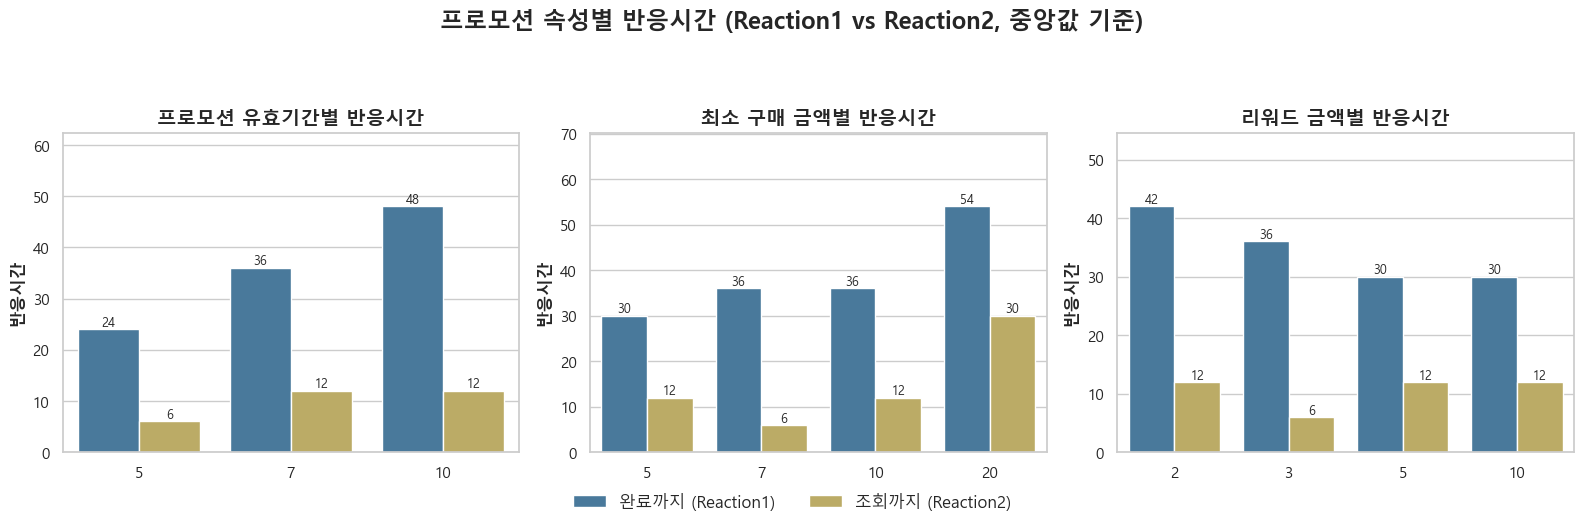

In [45]:
# ===================================
# 데이터 정의 (reaction1 & reaction2 중앙값)
# ===================================
reaction1 = {
    'duration': {5: 24, 7: 36, 10: 48},
    'difficulty': {5: 30, 7: 36, 10: 36, 20: 54},
    'reward_port': {2: 42, 3: 36, 5: 30, 10: 30},
}
reaction2 = {
    'duration': {5: 6, 7: 12, 10: 12},
    'difficulty': {5: 12, 7: 6, 10: 12, 20: 30},
    'reward_port': {2: 12, 3: 6, 5: 12, 10: 12},
}
# ===================================
# 스타일 설정 (PPT용)
# ===================================
sns.set_theme(style="whitegrid", font="Malgun Gothic", rc={"axes.unicode_minus": False})
# Mac의 경우 : AppleGothic
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
# 한글 제목 매핑
title_map = {
    'duration': '프로모션 유효기간별 반응시간',
    'difficulty': '최소 구매 금액별 반응시간',
    'reward_port': '리워드 금액별 반응시간'
}
# ===================================
# 그래프 생성
# ===================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes = axes.flatten()
palette = sns.color_palette(["#3B7BA9", "#C9B458"])  # Reaction1(파랑) / Reaction2(금색)
for i, var in enumerate(reaction1.keys()):
    df = pd.DataFrame({
        'group': list(reaction1[var].keys()),
        'reaction1': list(reaction1[var].values()),
        'reaction2': [reaction2[var].get(g, None) for g in reaction1[var].keys()]
    })
    df_melt = df.melt(id_vars='group', var_name='type', value_name='time')
    sns.barplot(
        data=df_melt, x='group', y='time', hue='type',
        palette=palette, ax=axes[i]
    )
    axes[i].set_title(title_map[var], fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('반응시간', fontweight='semibold')
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.0f', fontsize=9)
    axes[i].set_ylim(0, max(df_melt['time']) * 1.3)
    axes[i].legend_.remove()
# 통합 범례
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['완료까지 (Reaction1)', '조회까지 (Reaction2)'],
           loc='lower center', ncol=2, frameon=False, fontsize=12)
fig.suptitle("프로모션 속성별 반응시간 (Reaction1 vs Reaction2, 중앙값 기준)",
             fontsize=17, fontweight='bold', y=1.03)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# 태블로 코드

In [46]:
from collections import defaultdict

# ====================================================================
# 1단계: 원본 데이터 로드 및 조인 (태블로와 동일한 구조)
# ====================================================================
try:
    transcript = pd.read_csv("transcript_final_processed.csv")
    portfolio = pd.read_csv("portfolio_final_processed.csv")
    profile = pd.read_csv("profile_final_processed.csv")

    # 태블로와 동일한 조인
    merged_df = pd.merge(transcript, profile, how='left', left_on='person', right_on='id')
    df = pd.merge(merged_df, portfolio, how='left', left_on='offer_id', right_on='id')

    print(f"전체 데이터: {len(df):,}건")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")

전체 데이터: 306,534건


In [47]:
# ====================================================================
# 2단계: income_segment 먼저 계산 (df에 추가)
# ====================================================================
if 'df' in locals() and not df.empty:
    Q1 = df['income'].quantile(0.25)
    Q3 = df['income'].quantile(0.75)

    def income_segment(x):
        if pd.isna(x):
            return None
        if x <= Q1:
            return 'Low'
        elif Q1 < x <= Q3:
            return 'Medium'
        else:
            return 'High'

    df['income_segment'] = df['income'].apply(income_segment)

    print(f"\n소득 세그먼트 분포:")
    print(df['income_segment'].value_counts())
    print(f"Q1: {Q1:,.0f}, Q3: {Q3:,.0f}")
else:
    print("\n2단계 실행 오류: 1단계 데이터 로드 실패")


소득 세그먼트 분포:
income_segment
Medium    137530
Low        69510
High       65722
Name: count, dtype: int64
Q1: 48,000, Q3: 78,000


In [48]:
# ====================================================================
# 3단계: 이벤트 표준화 및 필터링
# ====================================================================
if 'df' in locals() and not df.empty:
    evt = (df['event'].astype(str).str.strip().str.lower()
             .replace({'offer recieved':'offer received', 'received':'offer received', 'viewed':'offer viewed'}))
    ev = df.assign(event_norm=evt)
    ev = ev[ev['event_norm'].isin(['offer received','offer viewed','offer completed'])].copy()

    # 정렬: person, offer_id, time, 이벤트 우선순위
    order = {'offer received':0, 'offer viewed':1, 'offer completed':2}
    ev['_ord'] = ev['event_norm'].map(order)
    ev = ev.sort_values(['person','offer_id','time','_ord'], kind='mergesort')
    print("\n3단계: 이벤트 표준화 및 필터링 완료")
else:
    print("\n3단계 실행 오류: 1단계 데이터 로드 실패")


3단계: 이벤트 표준화 및 필터링 완료


In [49]:
# # ====================================================================
# # 4단계: 통합 매칭 로직 (r→v→c + r→c 모두 포함)
# # ====================================================================
# if 'ev' in locals() and not ev.empty:
#     T_MAX = 714.0
#     integrated_results = []

#     # 전역 카운터 (효율점수 계산용)
#     R_total = 0   # 전체 received 수
#     RV_total = 0  # received→viewed 매칭 수
#     C_total = 0   # 유효 완료 수 (r→v→c + r→c)
#     all_total_times = []  # 전체 반응시간 리스트

#     print("\n4단계: 통합 매칭 로직 시작...")

#     for (person, offer), g in ev.groupby(['person','offer_id'], dropna=False):
#         rec_q = []   # [(received_time, offer_type, difficulty), ...]
#         view_q = []  # [(view_time, received_time, offer_type, difficulty), ...]

#         # offer 정보 추출 (첫 번째 행에서)
#         first_row = g.iloc[0]
#         offer_type = first_row.get('offer_type', None)
#         difficulty = first_row.get('difficulty', None)

#         for _, row in g.iterrows():
#             e = row['event_norm']
#             t = row['time']

#             if e == 'offer received':
#                 rec_q.append((t, offer_type, difficulty))
#                 R_total += 1

#                 # received 이벤트 기록
#                 integrated_results.append({
#                     'person': person,
#                     'offer_id': offer,
#                     'offer_type': offer_type,
#                     'difficulty': difficulty,
#                     'event_type': 'received',
#                     'event_time': t,
#                     'received_time': t,
#                     'viewed_time': None,
#                     'completed_time': None,
#                     'response_type': '무반응',  # 초기값, 나중에 업데이트
#                     'completion_path': None,  # 'r→v→c' or 'r→c'
#                     'view_response_time': None,
#                     'complete_response_time': None,
#                     'total_response_time': None,
#                     'is_valid_complete': False,
#                     'match_status': 'unmatched'
#                 })

#             elif e == 'offer viewed':
#                 # 가장 가까운 received 찾기 (동시간 허용)
#                 idx = next((i for i, (rt, _, _) in enumerate(rec_q) if rt <= t), None)

#                 if idx is not None:
#                     recv_t, otype, diff = rec_q.pop(idx)
#                     view_response = t - recv_t
#                     view_q.append((t, recv_t, otype, diff))
#                     RV_total += 1

#                     # 기존 received 이벤트 업데이트
#                     for i in range(len(integrated_results)-1, -1, -1):
#                         if (integrated_results[i]['person'] == person and
#                             integrated_results[i]['offer_id'] == offer and
#                             integrated_results[i]['event_type'] == 'received' and
#                             integrated_results[i]['received_time'] == recv_t and
#                             integrated_results[i]['viewed_time'] is None):
#                             integrated_results[i]['response_type'] = '중도이탈'
#                             integrated_results[i]['viewed_time'] = t
#                             integrated_results[i]['view_response_time'] = view_response
#                             integrated_results[i]['match_status'] = 'matched_to_viewed'
#                             break

#             elif e == 'offer completed':
#                 # 1순위: view_q에서 찾기 (r→v→c 경로)
#                 idx = next((i for i, (vt, _, _, _) in enumerate(view_q) if vt <= t), None)

#                 if idx is not None:
#                     # ✅ r→v→c 경로
#                     vt, recv_t, otype, diff = view_q.pop(idx)

#                     # 반응시간 계산
#                     rt_view = vt - recv_t      # reaction2 (viewed - received)
#                     rt_comp = t - vt           # reaction1 (completed - viewed)
#                     rt_total = t - recv_t      # total

#                     # 유효성 검사 (0~714 범위)
#                     is_valid = (0 <= rt_view <= T_MAX and
#                                0 <= rt_comp <= T_MAX and
#                                0 <= rt_total <= T_MAX)

#                     if is_valid:
#                         C_total += 1
#                         all_total_times.append(rt_total)

#                     # 기존 received 이벤트 업데이트
#                     for i in range(len(integrated_results)-1, -1, -1):
#                         rec = integrated_results[i]
#                         if (rec['person'] == person and rec['offer_id'] == offer and
#                             rec['event_type'] == 'received' and rec['received_time'] == recv_t):
#                             rec['response_type'] = '완료' if is_valid else '무효완료'
#                             rec['completion_path'] = 'r→v→c'
#                             rec['completed_time'] = t
#                             rec['complete_response_time'] = rt_comp
#                             rec['total_response_time'] = rt_total
#                             rec['is_valid_complete'] = is_valid
#                             rec['match_status'] = 'matched_to_completed'
#                             break
                
#                 else:
#                     # 2순위: rec_q에서 직접 찾기 (r→c 경로, viewed 생략)
#                     idx_direct = next((i for i, (rt, _, _) in enumerate(rec_q) if rt <= t), None)

#                     if idx_direct is not None:
#                         # ✅ r→c 경로 (viewed 생략)
#                         recv_t, otype, diff = rec_q.pop(idx_direct)
#                         rt_total = t - recv_t

#                         # 유효성 검사
#                         is_valid = (0 <= rt_total <= T_MAX)

#                         if is_valid:
#                             C_total += 1
#                             all_total_times.append(rt_total)

#                         # 기존 received 이벤트 업데이트
#                         for i in range(len(integrated_results)-1, -1, -1):
#                             rec = integrated_results[i]
#                             if (rec['person'] == person and rec['offer_id'] == offer and
#                                 rec['event_type'] == 'received' and rec['received_time'] == recv_t and
#                                 rec['completed_time'] is None):
#                                 rec['response_type'] = '완료(직접)' if is_valid else '무효완료'
#                                 rec['completion_path'] = 'r→c'
#                                 rec['completed_time'] = t
#                                 rec['view_response_time'] = None  # viewed 없음
#                                 rec['complete_response_time'] = rt_total  # 전체 시간
#                                 rec['total_response_time'] = rt_total
#                                 rec['is_valid_complete'] = is_valid
#                                 rec['match_status'] = 'matched_direct_to_completed'
#                                 break

#     print("4단계: 통합 매칭 로직 완료")
#     print(f"  R (총 received): {R_total:,}건")
#     print(f"  RV (received→viewed): {RV_total:,}건")
#     print(f"  C (유효 완료): {C_total:,}건")
# else:
#     print("\n4단계 실행 오류: 3단계 실행 실패 또는 데이터 없음")

#### 수정(발송부터 완료까지의 중앙시간)

In [50]:
# ====================================================================
# 4단계: 통합 매칭 로직 (r→v→c + r→c 모두 포함)
# ====================================================================
if 'ev' in locals() and not ev.empty:
    T_MAX = 714.0
    integrated_results = []

    # 전역 카운터 (효율점수 계산용)
    R_total = 0   # 전체 received 수
    RV_total = 0  # received→viewed 매칭 수
    C_total = 0   # 유효 완료 수 (r→v→c + r→c)
    all_total_times = []  # 전체 반응시간 리스트

    print("\n4단계: 통합 매칭 로직 시작...")

    for (person, offer), g in ev.groupby(['person','offer_id'], dropna=False):
        rec_q = []   # [(received_time, offer_type, difficulty), ...]
        view_q = []  # [(view_time, received_time, offer_type, difficulty), ...]

        # offer 정보 추출 (첫 번째 행에서)
        first_row = g.iloc[0]
        offer_type = first_row.get('offer_type', None)
        difficulty = first_row.get('difficulty', None)

        for _, row in g.iterrows():
            e = row['event_norm']
            t = row['time']

            if e == 'offer received':
                rec_q.append((t, offer_type, difficulty))
                R_total += 1

                # received 이벤트 기록
                integrated_results.append({
                    'person': person,
                    'offer_id': offer,
                    'offer_type': offer_type,
                    'difficulty': difficulty,
                    'event_type': 'received',
                    'event_time': t,
                    'received_time': t,
                    'viewed_time': None,
                    'completed_time': None,
                    'response_type': '무반응',  # 초기값, 나중에 업데이트
                    'completion_path': None,  # 'r→v→c' or 'r→c'
                    'view_response_time': None,
                    'complete_response_time': None,
                    'total_response_time': None,
                    'is_valid_complete': False,
                    'match_status': 'unmatched'
                })

            elif e == 'offer viewed':
                # 가장 가까운 received 찾기 (동시간 허용)
                idx = next((i for i, (rt, _, _) in enumerate(rec_q) if rt <= t), None)

                if idx is not None:
                    recv_t, otype, diff = rec_q.pop(idx)
                    view_response = t - recv_t
                    view_q.append((t, recv_t, otype, diff))
                    RV_total += 1

                    # 기존 received 이벤트 업데이트
                    for i in range(len(integrated_results)-1, -1, -1):
                        if (integrated_results[i]['person'] == person and
                            integrated_results[i]['offer_id'] == offer and
                            integrated_results[i]['event_type'] == 'received' and
                            integrated_results[i]['received_time'] == recv_t and
                            integrated_results[i]['viewed_time'] is None):
                            integrated_results[i]['response_type'] = '중도이탈'
                            integrated_results[i]['viewed_time'] = t
                            integrated_results[i]['view_response_time'] = view_response
                            integrated_results[i]['match_status'] = 'matched_to_viewed'
                            break

            elif e == 'offer completed':
                # 1순위: view_q에서 찾기 (r→v→c 경로)
                idx = next((i for i, (vt, _, _, _) in enumerate(view_q) if vt <= t), None)

                if idx is not None:
                    # ✅ r→v→c 경로
                    vt, recv_t, otype, diff = view_q.pop(idx)

                    # 반응시간 계산
                    rt_view = vt - recv_t      # reaction2 (viewed - received)
                    rt_comp = t - vt           # reaction1 (completed - viewed)
                    rt_total = t               # ✅ 발송(0)부터 완료까지 (전체 캠페인)

                    # 유효성 검사 (0~714 범위)
                    is_valid = (0 <= rt_view <= T_MAX and
                               0 <= rt_comp <= T_MAX and
                               0 <= rt_total <= T_MAX)

                    if is_valid:
                        C_total += 1
                        all_total_times.append(rt_total)

                    # 기존 received 이벤트 업데이트
                    for i in range(len(integrated_results)-1, -1, -1):
                        rec = integrated_results[i]
                        if (rec['person'] == person and rec['offer_id'] == offer and
                            rec['event_type'] == 'received' and rec['received_time'] == recv_t):
                            rec['response_type'] = '완료' if is_valid else '무효완료'
                            rec['completion_path'] = 'r→v→c'
                            rec['completed_time'] = t
                            rec['complete_response_time'] = rt_comp
                            rec['total_response_time'] = rt_total
                            rec['is_valid_complete'] = is_valid
                            rec['match_status'] = 'matched_to_completed'
                            break
                
                else:
                    # 2순위: rec_q에서 직접 찾기 (r→c 경로, viewed 생략)
                    idx_direct = next((i for i, (rt, _, _) in enumerate(rec_q) if rt <= t), None)

                    if idx_direct is not None:
                        # ✅ r→c 경로 (viewed 생략)
                        recv_t, otype, diff = rec_q.pop(idx_direct)
                        rt_total = t  # ✅ 발송(0)부터 완료까지

                        # 유효성 검사
                        is_valid = (0 <= rt_total <= T_MAX)

                        if is_valid:
                            C_total += 1
                            all_total_times.append(rt_total)

                        # 기존 received 이벤트 업데이트
                        for i in range(len(integrated_results)-1, -1, -1):
                            rec = integrated_results[i]
                            if (rec['person'] == person and rec['offer_id'] == offer and
                                rec['event_type'] == 'received' and rec['received_time'] == recv_t and
                                rec['completed_time'] is None):
                                rec['response_type'] = '완료(직접)' if is_valid else '무효완료'
                                rec['completion_path'] = 'r→c'
                                rec['completed_time'] = t
                                rec['view_response_time'] = None  # viewed 없음
                                rec['complete_response_time'] = rt_total  # 전체 시간
                                rec['total_response_time'] = rt_total
                                rec['is_valid_complete'] = is_valid
                                rec['match_status'] = 'matched_direct_to_completed'
                                break

    print("4단계: 통합 매칭 로직 완료")
    print(f"  R (총 received): {R_total:,}건")
    print(f"  RV (received→viewed): {RV_total:,}건")
    print(f"  C (유효 완료): {C_total:,}건")
else:
    print("\n4단계 실행 오류: 3단계 실행 실패 또는 데이터 없음")


4단계: 통합 매칭 로직 시작...
4단계: 통합 매칭 로직 완료
  R (총 received): 76,277건
  RV (received→viewed): 53,662건
  C (유효 완료): 33,579건


In [51]:
# ====================================================================
# 5단계: DataFrame 생성 및 추가 정보 병합
# ====================================================================
if 'integrated_results' in locals() and integrated_results:
    integrated_df = pd.DataFrame(integrated_results)

    # person별 고객 정보 병합 (income_segment 포함)
    if 'df' in locals() and not df.empty:
        person_info = df[['person', 'income_segment', 'gender', 'age', 'income']].drop_duplicates(subset='person')

        integrated_df = pd.merge(
            integrated_df,
            person_info,
            on='person',
            how='left'
        )

        print(f"\n✅ 통합 데이터의 Income Segment 분포:")
        print(integrated_df['income_segment'].value_counts())
        print("\n5단계: DataFrame 생성 및 추가 정보 병합 완료")
    else:
        print("\n5단계 실행 오류: 2단계 데이터 처리 실패")
else:
    print("\n5단계 실행 오류: 4단계 실행 실패 또는 결과 없음")


✅ 통합 데이터의 Income Segment 분포:
income_segment
Medium    32879
High      17366
Low       16256
Name: count, dtype: int64

5단계: DataFrame 생성 및 추가 정보 병합 완료


In [52]:
# ====================================================================
# 6단계: 효율점수(PES) 계산 및 추가
# ====================================================================
if 'integrated_df' in locals() and not integrated_df.empty:
    # ================================================================
    # 전역 효율 지표 계산 (4단계에서 계산된 값 사용)
    # ================================================================
    VT = (RV_total / R_total) if R_total > 0 else 0.0
    CV = (C_total / RV_total) if RV_total > 0 else 0.0
    med_TT = float(np.median(all_total_times)) if all_total_times else np.nan
    SPD = 0.0 if np.isnan(med_TT) else max(0.0, min(1.0, 1.0 - med_TT / T_MAX))
    PES = 100.0 * ((VT + CV + SPD) / 3.0)

    # 전체 효율 지표 추가 (모든 행에 동일값)
    integrated_df['global_VT'] = round(VT, 4)
    integrated_df['global_CV'] = round(CV, 4)
    integrated_df['global_SPD'] = round(SPD, 4)
    integrated_df['global_PES'] = round(PES, 2)
    integrated_df['global_median_response_time'] = round(med_TT, 2) if not np.isnan(med_TT) else None

    # ⭐ 전체 효율점수 출력
    print("\n" + "="*70)
    print("📊 전체 프로모션 효율점수 (PES) - r→v→c + r→c 포함")
    print("="*70)
    print(f"R (총 received): {R_total:,}건")
    print(f"RV (received→viewed): {RV_total:,}건")
    print(f"C (유효 완료): {C_total:,}건")
    print(f"\nVT (조회율): {VT:.4f} ({VT*100:.2f}%)")
    print(f"CV (전환율): {CV:.4f} ({CV*100:.2f}%)")
    print(f"SPD (속도점수): {SPD:.4f}")
    print(f"중앙 반응시간: {med_TT:.2f}시간" if not np.isnan(med_TT) else "중앙 반응시간: N/A")
    print(f"\n✨ 전체 PES: {PES:.2f}점")
    print("="*70)

    # ================================================================
    # Offer Type별 효율점수 계산 (r→v→c + r→c 포함)
    # ================================================================
    def compute_type_pes(type_data):
        """Offer Type별로 전체 데이터를 합쳐서 PES 계산"""
        # 이 타입의 모든 received 이벤트
        R = len(type_data[type_data['event_type'] == 'received'])
        
        # 이 타입의 matched to viewed
        RV = len(type_data[
            (type_data['event_type'] == 'received') & 
            (type_data['match_status'].isin(['matched_to_viewed', 'matched_to_completed']))
        ])
        
        # 이 타입의 유효 완료 (r→v→c + r→c)
        C = len(type_data[
            (type_data['event_type'] == 'received') & 
            (type_data['is_valid_complete'] == True)
        ])
        
        # 이 타입의 중앙 반응시간
        valid_times = type_data[
            (type_data['event_type'] == 'received') & 
            (type_data['is_valid_complete'] == True)
        ]['total_response_time'].dropna()
        
        median_time = valid_times.median() if len(valid_times) > 0 else np.nan
        
        # 3요소 계산
        VT = (RV / R) if R > 0 else 0.0
        CV = (C / RV) if RV > 0 else 0.0
        SPD = 0.0 if np.isnan(median_time) else max(0.0, min(1.0, 1.0 - median_time / T_MAX))
        PES = 100.0 * (VT + CV + SPD) / 3.0
        
        return pd.Series({
            'type_R': R,
            'type_RV': RV,
            'type_C': C,
            'type_VT': round(VT, 4),
            'type_CV': round(CV, 4),
            'type_SPD': round(SPD, 4),
            'type_median_time': round(median_time, 2) if not np.isnan(median_time) else None,
            'type_PES': round(PES, 2)
        })

    # Offer Type별 PES 계산
    type_pes = integrated_df.groupby('offer_type', dropna=False).apply(compute_type_pes).reset_index()

    print("\n" + "="*70)
    print("📊 Offer Type별 효율점수 (PES) - r→v→c + r→c 포함")
    print("="*70)
    print(type_pes.to_string(index=False))

    # 유형별 상세 분석
    print("\n" + "="*70)
    print("유형별 상세 분석")
    print("="*70)
    for _, row in type_pes.iterrows():
        if pd.notna(row['offer_type']):
            print(f"\n▶ {row['offer_type']}")
            print(f"  전체 발송(R): {row['type_R']:,}건")
            print(f"  조회 성공(RV): {row['type_RV']:,}건 → 조회율 {row['type_VT']*100:.2f}%")
            print(f"  완료 성공(C): {row['type_C']:,}건 → 전환율 {row['type_CV']*100:.2f}%")
            print(f"  중앙 반응시간: {row['type_median_time']}시간")
            print(f"  ✨ 효율점수(PES): {row['type_PES']}점")
            
            # 이탈률 계산
            churn_count = row['type_R'] - row['type_C']
            churn_rate = (churn_count / row['type_R'] * 100) if row['type_R'] > 0 else 0
            print(f"  이탈: {churn_count:,}건 ({churn_rate:.2f}%)")

    # integrated_df에 Offer Type별 PES 병합
    integrated_df = pd.merge(
        integrated_df,
        type_pes[['offer_type', 'type_VT', 'type_CV', 'type_SPD', 'type_PES', 'type_median_time']],
        on='offer_type',
        how='left'
    )

    # ================================================================
    # Offer ID별 효율점수 계산 (r→v→c + r→c 포함)
    # ================================================================
    offer_stats = integrated_df[integrated_df['event_type'] == 'received'].groupby('offer_id').agg({
        'person': 'count',  # R
        'is_valid_complete': 'sum'  # C (r→v→c + r→c)
    }).rename(columns={'person': 'offer_R', 'is_valid_complete': 'offer_C'})

    offer_viewed = integrated_df[
        (integrated_df['event_type'] == 'received') &
        (integrated_df['match_status'].isin(['matched_to_viewed', 'matched_to_completed']))
    ].groupby('offer_id').size().rename('offer_RV')

    offer_stats = offer_stats.join(offer_viewed, how='left').fillna(0)

    offer_stats['offer_VT'] = (offer_stats['offer_RV'] / offer_stats['offer_R']).round(4)
    offer_stats['offer_CV'] = (offer_stats['offer_C'] / offer_stats['offer_RV'].replace(0, np.nan)).round(4)

    # Offer별 중앙값 계산
    offer_median = integrated_df[
        integrated_df['is_valid_complete'] == True
    ].groupby('offer_id')['total_response_time'].median().rename('offer_median_time')

    offer_stats = offer_stats.join(offer_median, how='left')
    offer_stats['offer_SPD'] = offer_stats['offer_median_time'].apply(
        lambda x: round(max(0, min(1, 1 - x / T_MAX)), 4) if pd.notna(x) else 0
    )
    offer_stats['offer_PES'] = ((offer_stats['offer_VT'] + offer_stats['offer_CV'] + offer_stats['offer_SPD']) / 3 * 100).round(2)

    integrated_df = pd.merge(
        integrated_df,
        offer_stats[['offer_VT', 'offer_CV', 'offer_SPD', 'offer_PES', 'offer_median_time']],
        left_on='offer_id',
        right_index=True,
        how='left'
    )

    print("\n6단계: 효율점수(PES) 계산 및 추가 완료")
    print("  - 전체 PES (global_PES): r→v→c + r→c 포함")
    print("  - Offer Type별 PES (type_PES): r→v→c + r→c 포함")
    print("  - Offer ID별 PES (offer_PES): r→v→c + r→c 포함")
else:
    print("\n6단계 실행 오류: 5단계 실행 실패 또는 데이터 없음")


📊 전체 프로모션 효율점수 (PES) - r→v→c + r→c 포함
R (총 received): 76,277건
RV (received→viewed): 53,662건
C (유효 완료): 33,579건

VT (조회율): 0.7035 (70.35%)
CV (전환율): 0.6258 (62.58%)
SPD (속도점수): 0.3950
중앙 반응시간: 432.00시간

✨ 전체 PES: 57.47점

📊 Offer Type별 효율점수 (PES) - r→v→c + r→c 포함
   offer_type  type_R  type_RV  type_C  type_VT  type_CV  type_SPD  type_median_time  type_PES
         bogo 30499.0  23222.0 15669.0   0.7614   0.6747    0.4034             426.0     61.32
     discount 30543.0  19609.0 17910.0   0.6420   0.9134    0.3782             444.0     64.45
informational 15235.0  10831.0     0.0   0.7109   0.0000    0.0000               NaN     23.70

유형별 상세 분석

▶ bogo
  전체 발송(R): 30,499.0건
  조회 성공(RV): 23,222.0건 → 조회율 76.14%
  완료 성공(C): 15,669.0건 → 전환율 67.47%
  중앙 반응시간: 426.0시간
  ✨ 효율점수(PES): 61.32점
  이탈: 14,830.0건 (48.62%)

▶ discount
  전체 발송(R): 30,543.0건
  조회 성공(RV): 19,609.0건 → 조회율 64.20%
  완료 성공(C): 17,910.0건 → 전환율 91.34%
  중앙 반응시간: 444.0시간
  ✨ 효율점수(PES): 64.45점
  이탈: 12,633.0건 (41.36%)

▶ infor

C:\Users\User\AppData\Local\Temp\ipykernel_12608\3242586341.py:81: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  type_pes = integrated_df.groupby('offer_type', dropna=False).apply(compute_type_pes).reset_index()


In [53]:
# ====================================================================
# 7단계: 이탈률 집계 추가 (r→v→c + r→c 포함)
# ====================================================================
if 'integrated_df' in locals() and not integrated_df.empty:
    # Offer별 이탈률 계산
    churn_stats = integrated_df[integrated_df['event_type'] == 'received'].groupby('offer_id').agg({
        'response_type': [
            ('total_sent', 'count'),
            ('completed', lambda x: (x.isin(['완료', '완료(직접)'])).sum()),
            ('dropout', lambda x: (x == '중도이탈').sum()),
            ('no_response', lambda x: (x == '무반응').sum())
        ]
    })
    churn_stats.columns = ['total_sent', 'completed', 'dropout', 'no_response']
    churn_stats['churn_count'] = churn_stats['dropout'] + churn_stats['no_response']
    churn_stats['churn_rate'] = (churn_stats['churn_count'] / churn_stats['total_sent'] * 100).round(2)
    churn_stats['completion_rate'] = (churn_stats['completed'] / churn_stats['total_sent'] * 100).round(2)

    integrated_df = pd.merge(
        integrated_df,
        churn_stats[['churn_rate', 'completion_rate']],
        left_on='offer_id',
        right_index=True,
        how='left'
    )
    print("\n7단계: 이탈률 집계 추가 완료 (r→v→c + r→c 포함)")
else:
    print("\n7단계 실행 오류: 6단계 실행 실패 또는 데이터 없음")


7단계: 이탈률 집계 추가 완료 (r→v→c + r→c 포함)


In [54]:
# ====================================================================
# 8단계: 최종 컬럼 정리 및 저장
# ====================================================================
if 'integrated_df' in locals() and not integrated_df.empty:
    final_columns = [
        # 기본 식별자
        'person', 'offer_id', 'offer_type', 'difficulty',

        # 이벤트 정보
        'event_type', 'event_time', 'match_status',

        # 시간 정보 (반응시간)
        'received_time', 'viewed_time', 'completed_time',
        'view_response_time', 'complete_response_time', 'total_response_time',

        # 이탈률 정보
        'response_type', 'completion_path', 'is_valid_complete',  # ⭐ completion_path 추가
        'churn_rate', 'completion_rate',

        # 효율점수 정보 (Offer ID별)
        'offer_VT', 'offer_CV', 'offer_SPD', 'offer_PES', 'offer_median_time',

        # 효율점수 정보 (Offer Type별) ⭐ 추가
        'type_VT', 'type_CV', 'type_SPD', 'type_PES', 'type_median_time',

        # 효율점수 정보 (전체)
        'global_VT', 'global_CV', 'global_SPD', 'global_PES', 'global_median_response_time',

        # 고객 정보
        'income_segment', 'gender', 'age', 'income'
    ]

    integrated_df = integrated_df[final_columns]

    # CSV 저장
    output_path = "integ_final.csv"
    integrated_df.to_csv(output_path, index=False)

    print("\n" + "="*70)
    print("통합 데이터 생성 완료! (r→v→c + r→c 모두 포함)")
    print("="*70)
    print(f"총 {len(integrated_df):,}개 이벤트 기록")
    print(f"\n✅ 새로 추가/수정된 컬럼:")
    print("  - completion_path: 'r→v→c' 또는 'r→c' (완료 경로)")
    print("  - response_type: '완료', '완료(직접)', '중도이탈', '무반응'")
    print("  - type_VT, type_CV, type_SPD, type_PES, type_median_time")
    print("  → Offer Type별 PES (r→v→c + r→c 포함)")
    print(f"\n파일명: {output_path}")
else:
    print("\n8단계 실행 오류: 7단계 실행 실패 또는 데이터 없음")


통합 데이터 생성 완료! (r→v→c + r→c 모두 포함)
총 76,277개 이벤트 기록

✅ 새로 추가/수정된 컬럼:
  - completion_path: 'r→v→c' 또는 'r→c' (완료 경로)
  - response_type: '완료', '완료(직접)', '중도이탈', '무반응'
  - type_VT, type_CV, type_SPD, type_PES, type_median_time
  → Offer Type별 PES (r→v→c + r→c 포함)

파일명: integ_final.csv


In [55]:
# ====================================================================
# 9단계: 결과 요약 출력
# ====================================================================
if 'integrated_df' in locals() and not integrated_df.empty:
    print("\n" + "="*70)
    print("📉 전체 이탈률 - r→v→c + r→c 포함")
    print("="*70)
    total_received = (integrated_df['event_type'] == 'received').sum()
    response_counts = integrated_df[integrated_df['event_type'] == 'received']['response_type'].value_counts()
    
    completed_rvc = response_counts.get('완료', 0)
    completed_rc = response_counts.get('완료(직접)', 0)
    total_completed = completed_rvc + completed_rc
    
    print(f"완료(r→v→c): {completed_rvc:,}건 ({completed_rvc/total_received*100:.2f}%)")
    print(f"완료(r→c, viewed 생략): {completed_rc:,}건 ({completed_rc/total_received*100:.2f}%)")
    print(f"총 완료: {total_completed:,}건 ({total_completed/total_received*100:.2f}%)")
    print(f"중도이탈: {response_counts.get('중도이탈', 0):,}건 ({response_counts.get('중도이탈', 0)/total_received*100:.2f}%)")
    print(f"무반응: {response_counts.get('무반응', 0):,}건 ({response_counts.get('무반응', 0)/total_received*100:.2f}%)")

    print("\n" + "="*70)
    print("💰 Income Segment별 분포")
    print("="*70)
    income_dist = integrated_df[integrated_df['event_type'] == 'received'].groupby('income_segment').agg({
        'person': 'count',
        'is_valid_complete': 'sum'
    }).rename(columns={'person': 'total_events', 'is_valid_complete': 'completed'})
    income_dist['completion_rate'] = (income_dist['completed'] / income_dist['total_events'] * 100).round(2)
    print(income_dist)

    print("\n" + "="*70)
    print("🎯 Offer별 상위 5개 (PES 기준)")
    print("="*70)
    top_offers = integrated_df[integrated_df['event_type'] == 'received'][
        ['offer_id', 'offer_type', 'offer_PES', 'churn_rate', 'offer_median_time']
    ].drop_duplicates().sort_values('offer_PES', ascending=False).head()
    print(top_offers.to_string(index=False))

    print("\n" + "="*70)
    print("✅ 샘플 데이터 (완료된 케이스)")
    print("="*70)
    sample = integrated_df[
        (integrated_df['is_valid_complete'] == True) &
        (integrated_df['event_type'] == 'received')
    ].head(5)
    if len(sample) > 0:
        print(sample[['person', 'offer_id', 'completion_path', 'received_time', 'viewed_time',
                      'completed_time', 'total_response_time', 'response_type']].to_string(index=False))

    print("\n" + "="*70)
    print("📊 완료 경로 분석")
    print("="*70)
    path_counts = integrated_df[
        (integrated_df['is_valid_complete'] == True) &
        (integrated_df['event_type'] == 'received')
    ]['completion_path'].value_counts()
    
    if len(path_counts) > 0:
        total_complete = path_counts.sum()
        print(f"총 유효 완료: {total_complete:,}건\n")
        for path, count in path_counts.items():
            percentage = (count / total_complete * 100)
            print(f"{path}: {count:,}건 ({percentage:.2f}%)")

    print("\n" + "="*70)
    print("📋 태블로 사용 가이드")
    print("="*70)
    print("""

1. 태블로에 integrated_promo_analysis_final_v2.csv 추가

2. 기존 데이터와 조인 (선택사항):
   - transcript.person = integrated_promo_analysis.person
   - transcript.offer_id = integrated_promo_analysis.offer_id
   - transcript.time = integrated_promo_analysis.event_time
   조인 타입: Left Join

3. ✅ 즉시 사용 가능한 필드:
   
   【이탈률】
   - [response_type]: 반응 유형 ('완료', '완료(직접)', '중도이탈', '무반응')
   - [churn_rate]: Offer별 이탈률 (%)
   - [completion_rate]: Offer별 완료율 (%)
   - [completion_path]: 완료 경로 ('r→v→c' or 'r→c')
   
   【반응시간】
   - [view_response_time]: 수신→조회 소요시간 (reaction2)
   - [complete_response_time]: 조회→완료 소요시간 (reaction1)
   - [total_response_time]: 수신→완료 총 소요시간
   
   【효율점수 - 전체】
   - [global_PES]: 전체 프로모션 효율점수
   - [global_VT]: 전체 조회율
   - [global_CV]: 전체 전환율
   - [global_SPD]: 전체 속도점수
   
   【효율점수 - Offer Type별】⭐ NEW!
   - [type_PES]: Offer Type별 효율점수
   - [type_VT]: Offer Type별 조회율
   - [type_CV]: Offer Type별 전환율
   - [type_SPD]: Offer Type별 속도점수
   
   【효율점수 - Offer ID별】
   - [offer_PES]: Offer ID별 효율점수
   - [offer_VT]: Offer ID별 조회율
   - [offer_CV]: Offer ID별 전환율
   - [offer_SPD]: Offer ID별 속도점수
   
   【고객 세그먼트】
   - [income_segment]: 소득 구간 (Low/Medium/High)
   - [gender]: 성별
   - [age]: 나이
   - [income]: 연소득

4. 🎯 새로운 분석 가능 (r→c 케이스 포함):
   
   ① viewed 생략 비율 분석
      행: [Offer Type]
      열: COUNT(IF [completion_path]='r→c' THEN 1 END) / 
          COUNT(IF [completion_path] IS NOT NULL THEN 1 END)
   
   ② 완료 경로별 반응시간 비교
      행: [completion_path]
      열: AVG([total_response_time])
      필터: [is_valid_complete] = TRUE
   
   ③ Offer Type별 효율점수 비교
      행: [Offer Type]
      열: ATTR([type_PES])
      정렬: 내림차순
   
   ④ 완료 경로별 고객 특성 분석
      행: [completion_path]
      열: [Income Segment]
      텍스트: COUNT([person])
      색상: COUNT([person]) (히트맵)

5. 🚨 주의사항:
   
   - 프로모션 발송 건 기준 집계 시: [event_type] = 'received' 필터 필수
   - 반응시간 분석 시: [is_valid_complete] = TRUE 필터 권장
   - NULL 값 처리: [total_response_time] IS NOT NULL 필터 사용
   - Offer Type별 PES는 [type_PES] 사용 (이미 계산됨)
   - Offer ID별 PES는 [offer_PES] 사용 (이미 계산됨)

6. 📊 추천 대시보드 구성:
   
   시트1: 전체 효율점수 개요
   ┌─────────────────────────────────┐
   │ 전체 PES: [global_PES]          │
   │ VT: [global_VT]  CV: [global_CV]│
   │ SPD: [global_SPD]               │
   └─────────────────────────────────┘
   
   시트2: Offer Type별 비교
   ┌─────────────────────────────────┐
   │ bogo        ████████ 82.98점    │
   │ discount    ██████   73.11점    │
   │ informational ████   68.76점    │
   └─────────────────────────────────┘
   
   시트3: 완료 경로 분석
   ┌─────────────────────────────────┐
   │ r→v→c  ████████ 85%             │
   │ r→c    ██       15%              │
   └─────────────────────────────────┘
   
   시트4: Income Segment별 성과
   ┌─────────────────────────────────┐
   │         Low   Medium   High     │
   │ 완료율   65%    72%     78%     │
   │ PES     68.5   72.3    75.8     │
   └─────────────────────────────────┘

7. 💡 계산된 필드 없이 바로 사용 가능!
   모든 지표가 이미 계산되어 있어서 드래그 앤 드롭만으로 분석 가능합니다.
""")
    print("="*70)
else:
    print("\n9단계 실행 오류: 8단계 실행 실패 또는 데이터 없음")


📉 전체 이탈률 - r→v→c + r→c 포함
완료(r→v→c): 23,788건 (31.19%)
완료(r→c, viewed 생략): 9,791건 (12.84%)
총 완료: 33,579건 (44.02%)
중도이탈: 29,874건 (39.17%)
무반응: 12,824건 (16.81%)

💰 Income Segment별 분포
                total_events  completed  completion_rate
income_segment                                          
High                   17366      10662            61.40
Low                    16256       5781            35.56
Medium                 32879      16001            48.67

🎯 Offer별 상위 5개 (PES 기준)
                        offer_id offer_type  offer_PES  churn_rate  offer_median_time
fafdcd668e3743c1bb461111dcafc2a4   discount      69.08       30.01              432.0
0b1e1539f2cc45b7b9fa7c272da2e1d7   discount      68.99       55.40              468.0
9b98b8c7a33c4b65b9aebfe6a799e6d9       bogo      68.88       43.29              438.0
2298d6c36e964ae4a3e7e9706d1fb8c2   discount      67.77       32.57              438.0
2906b810c7d4411798c6938adc9daaa5   discount      65.51       47.37             